In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Best test loss epoch
def find_best_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    best_epoch = df.loc[df[rmse_column].idxmin()]
    return int(best_epoch['Epoch']), best_epoch[rmse_column]

# Last epoch
def find_last_epoch(metrics_csv, rmse_column):
    df = pd.read_csv(metrics_csv)
    last_epoch = df.iloc[-1]
    return int(last_epoch['Epoch']), last_epoch[rmse_column]

def plot_comparative_lr_bert_log_file(metrics_csv_1b, metrics_csv_2b, metrics_csv_1e, metrics_csv_2e, coords, metrics_img, model):
    df1b = pd.read_csv(metrics_csv_1b)
    df2b = pd.read_csv(metrics_csv_2b)
    df1e = pd.read_csv(metrics_csv_1e)
    df2e = pd.read_csv(metrics_csv_2e)

    sns.set_theme(style="darkgrid")
    fig, ((ax1tr, ax2tr), (ax1te, ax2te)) = plt.subplots(2, 2, figsize=(16, 9))  # 2 rows, 2 columns
    fontsize = 14

    # Plot 1: Training Metrics (ADAM, LR=1e-4)
    ax1tr.plot(df1b['Epoch'], df1b[f'Train {model} RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1tr.plot(df1e['Epoch'], df1e[f'Train {model} RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1tr.tick_params(axis='x', labelsize=fontsize)    
    ax1tr.set_xlim(-50, 1050)
    ax1tr.set_ylabel('RMSE', fontsize=fontsize)
    ax1tr.tick_params(axis='y', labelsize=fontsize)
    ax1tr.set_ylim(-0.1, 3)
    ax1tr.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1tr.set_title('Training - ADAM, LR=1e-4', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (ADAM, LR=1e-4)
    ax1te.plot(df1b['Epoch'], df1b[f'Test {model} RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1te.plot(df1e['Epoch'], df1e[f'Test {model} RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1te.set_xlabel('Epochs', fontsize=fontsize)
    ax1te.tick_params(axis='x', labelsize=fontsize)
    ax1te.set_xlim(-50, 1050)
    ax1te.set_ylabel('RMSE', fontsize=fontsize)
    ax1te.tick_params(axis='y', labelsize=fontsize)
    ax1te.set_ylim(-0.1, 3)
    ax1te.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1te.set_title('Testing - ADAM, LR=1e-4', loc='right', fontsize=fontsize)

    # Plot 3: Training Metrics (ADAM, LR=1e-5)
    ax2tr.plot(df2b['Epoch'], df2b[f'Train {model} RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2tr.plot(df2e['Epoch'], df2e[f'Train {model} RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2tr.tick_params(axis='x', labelsize=fontsize)    
    ax2tr.set_xlim(-50, 1050)
    ax2tr.set_ylabel('')
    ax2tr.tick_params(axis='y', labelsize=fontsize)
    ax2tr.set_ylim(-0.1, 3)
    ax2tr.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2tr.set_title('Training - ADAM, LR=1e-5', loc='right', fontsize=fontsize)

    # Plot 4: Testing Metrics (ADAM, LR=1e-5)
    ax2te.plot(df2b['Epoch'], df2b[f'Test {model} RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2te.plot(df2e['Epoch'], df2e[f'Test {model} RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2te.set_xlabel('Epochs', fontsize=fontsize)
    ax2te.tick_params(axis='x', labelsize=fontsize)
    ax2te.set_xlim(-50, 1050)
    ax2te.set_ylabel('')
    ax2te.tick_params(axis='y', labelsize=fontsize)
    ax2te.set_ylim(-0.1, 3)
    ax2te.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2te.set_title('Testing - ADAM, LR=1e-5', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1b_rmse = find_best_epoch(metrics_csv_1b, f'Test {model} RMSE')
    best_df1e_rmse = find_best_epoch(metrics_csv_1e, f'Test {model} RMSE')
    best_df2b_rmse = find_best_epoch(metrics_csv_2b, f'Test {model} RMSE')
    best_df2e_rmse = find_best_epoch(metrics_csv_2e, f'Test {model} RMSE')
    
    print("Best test RMSE at epoch x:")
    print("- ADAM, LR=1e-4:")
    print(f"\tBinding: epoch {best_df1b_rmse[0]}, rmse {best_df1b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df1e_rmse[0]}, rmse {best_df1e_rmse[1]:.4f}")
    print("- ADAM, LR=1e-5:")
    print(f"\tBinding: epoch {best_df2b_rmse[0]}, rmse {best_df2b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df2e_rmse[0]}, rmse {best_df2e_rmse[1]:.4f}")

    ax1te.annotate(
        f'({best_df1b_rmse[0]}, {best_df1b_rmse[1]:.4f})', best_df1b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax1te.annotate(
        f'({best_df1e_rmse[0]}, {best_df1e_rmse[1]:.4f})', best_df1e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-4']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax2te.annotate(
        f'({best_df2b_rmse[0]}, {best_df2b_rmse[1]:.4f})', best_df2b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-5']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2te.annotate(
        f'({best_df2e_rmse[0]}, {best_df2e_rmse[1]:.4f})', best_df2e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

def plot_comparative_lr_log_file(metrics_csv_1b, metrics_csv_2b, metrics_csv_1e, metrics_csv_2e, coords, metrics_img):
    df1b = pd.read_csv(metrics_csv_1b)
    df2b = pd.read_csv(metrics_csv_2b)
    df1e = pd.read_csv(metrics_csv_1e)
    df2e = pd.read_csv(metrics_csv_2e)

    sns.set_theme(style="darkgrid")
    fig, ((ax1tr, ax2tr), (ax1te, ax2te)) = plt.subplots(2, 2, figsize=(16, 9))  # 2 rows, 2 columns
    fontsize = 14

    # Plot 1: Training Metrics (ADAM, LR=1e-4)
    ax1tr.plot(df1b['Epoch'], df1b[f'Train RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1tr.plot(df1e['Epoch'], df1e[f'Train RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1tr.tick_params(axis='x', labelsize=fontsize)    
    ax1tr.set_xlim(-50, 1050)
    ax1tr.set_ylabel('RMSE', fontsize=fontsize)
    ax1tr.tick_params(axis='y', labelsize=fontsize)
    ax1tr.set_ylim(-0.1, 3)
    ax1tr.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1tr.set_title('Training - ADAM, LR=1e-4', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (ADAM, LR=1e-4)
    ax1te.plot(df1b['Epoch'], df1b[f'Test RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1te.plot(df1e['Epoch'], df1e[f'Test RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax1te.set_xlabel('Epochs', fontsize=fontsize)
    ax1te.tick_params(axis='x', labelsize=fontsize)
    ax1te.set_xlim(-50, 1050)
    ax1te.set_ylabel('RMSE', fontsize=fontsize)
    ax1te.tick_params(axis='y', labelsize=fontsize)
    ax1te.set_ylim(-0.1, 3)
    ax1te.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1te.set_title('Testing - ADAM, LR=1e-4', loc='right', fontsize=fontsize)

    # Plot 3: Training Metrics (ADAM, LR=1e-5)
    ax2tr.plot(df2b['Epoch'], df2b[f'Train RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2tr.plot(df2e['Epoch'], df2e[f'Train RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2tr.tick_params(axis='x', labelsize=fontsize)    
    ax2tr.set_xlim(-50, 1050)
    ax2tr.set_ylabel('')
    ax2tr.tick_params(axis='y', labelsize=fontsize)
    ax2tr.set_ylim(-0.1, 3)
    ax2tr.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2tr.set_title('Training - ADAM, LR=1e-5', loc='right', fontsize=fontsize)

    # Plot 4: Testing Metrics (ADAM, LR=1e-5)
    ax2te.plot(df2b['Epoch'], df2b[f'Test RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2te.plot(df2e['Epoch'], df2e[f'Test RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)

    ax2te.set_xlabel('Epochs', fontsize=fontsize)
    ax2te.tick_params(axis='x', labelsize=fontsize)
    ax2te.set_xlim(-50, 1050)
    ax2te.set_ylabel('')
    ax2te.tick_params(axis='y', labelsize=fontsize)
    ax2te.set_ylim(-0.1, 3)
    ax2te.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2te.set_title('Testing - ADAM, LR=1e-5', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1b_rmse = find_best_epoch(metrics_csv_1b, f'Test RMSE')
    best_df1e_rmse = find_best_epoch(metrics_csv_1e, f'Test RMSE')
    best_df2b_rmse = find_best_epoch(metrics_csv_2b, f'Test RMSE')
    best_df2e_rmse = find_best_epoch(metrics_csv_2e, f'Test RMSE')
    
    print("Best test RMSE at epoch x:")
    print("- ADAM, LR=1e-4:")
    print(f"\tBinding: epoch {best_df1b_rmse[0]}, rmse {best_df1b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df1e_rmse[0]}, rmse {best_df1e_rmse[1]:.4f}")
    print("- ADAM, LR=1e-5:")
    print(f"\tBinding: epoch {best_df2b_rmse[0]}, rmse {best_df2b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df2e_rmse[0]}, rmse {best_df2e_rmse[1]:.4f}")

    ax1te.annotate(
        f'({best_df1b_rmse[0]}, {best_df1b_rmse[1]:.4f})', best_df1b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax1te.annotate(
        f'({best_df1e_rmse[0]}, {best_df1e_rmse[1]:.4f})', best_df1e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-4']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax2te.annotate(
        f'({best_df2b_rmse[0]}, {best_df2b_rmse[1]:.4f})', best_df2b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-5']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2te.annotate(
        f'({best_df2e_rmse[0]}, {best_df2e_rmse[1]:.4f})', best_df2e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

def plot_comparative_lr_BE_log_file(metrics_csv_1, metrics_csv_2, coords, metrics_img):
    df1 = pd.read_csv(metrics_csv_1)
    df2 = pd.read_csv(metrics_csv_2)

    sns.set_theme(style="darkgrid")
    fig, ((ax1tr, ax2tr), (ax1te, ax2te)) = plt.subplots(2, 2, figsize=(16, 9))  # 2 rows, 2 columns
    fontsize = 14

    # Plot 1: Training Metrics (ADAM, LR=1e-4)
    ax1tr.plot(df1['Epoch'], df1[f'Train Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1tr.plot(df1['Epoch'], df1[f'Train Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1tr.plot(df1['Epoch'], df1[f'Train BE RMSE'], label='Combined', color='tab:green', linestyle='-', linewidth=1.5)

    ax1tr.tick_params(axis='x', labelsize=fontsize)    
    ax1tr.set_xlim(-50, 1050)
    ax1tr.set_ylabel('RMSE', fontsize=fontsize)
    ax1tr.tick_params(axis='y', labelsize=fontsize)
    ax1tr.set_ylim(-0.1, 3)
    ax1tr.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1tr.set_title('Training - ADAM, LR=1e-4', loc='right', fontsize=fontsize)

    # Plot 2: Testing Metrics (ADAM, LR=1e-4)
    ax1te.plot(df1['Epoch'], df1[f'Test Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax1te.plot(df1['Epoch'], df1[f'Test Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)
    ax1te.plot(df1['Epoch'], df1[f'Test BE RMSE'], label='Combined', color='tab:green', linestyle='-', linewidth=1.5)

    ax1te.set_xlabel('Epochs', fontsize=fontsize)
    ax1te.tick_params(axis='x', labelsize=fontsize)
    ax1te.set_xlim(-50, 1050)
    ax1te.set_ylabel('RMSE', fontsize=fontsize)
    ax1te.tick_params(axis='y', labelsize=fontsize)
    ax1te.set_ylim(-0.1, 3)
    ax1te.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax1te.set_title('Testing - ADAM, LR=1e-4', loc='right', fontsize=fontsize)

    # Plot 3: Training Metrics (ADAM, LR=1e-5)
    ax2tr.plot(df2['Epoch'], df2[f'Train Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2tr.plot(df2['Epoch'], df2[f'Train Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2tr.plot(df2['Epoch'], df2[f'Train BE RMSE'], label='Combined', color='tab:green', linestyle='-', linewidth=1.5)

    ax2tr.tick_params(axis='x', labelsize=fontsize)    
    ax2tr.set_xlim(-50, 1050)
    ax2tr.set_ylabel('')
    ax2tr.tick_params(axis='y', labelsize=fontsize)
    ax2tr.set_ylim(-0.1, 3)
    ax2tr.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2tr.set_title('Training - ADAM, LR=1e-5', loc='right', fontsize=fontsize)

    # Plot 4: Testing Metrics (ADAM, LR=1e-5)
    ax2te.plot(df2['Epoch'], df2[f'Test Binding RMSE'], label='Binding', color='tab:blue', linestyle='-', linewidth=1.5)
    ax2te.plot(df2['Epoch'], df2[f'Test Expression RMSE'], label='Expression', color='tab:orange', linestyle='-', linewidth=1.5)
    ax2te.plot(df2['Epoch'], df2[f'Test BE RMSE'], label='Combined', color='tab:green', linestyle='-', linewidth=1.5)

    ax2te.set_xlabel('Epochs', fontsize=fontsize)
    ax2te.tick_params(axis='x', labelsize=fontsize)
    ax2te.set_xlim(-50, 1050)
    ax2te.set_ylabel('')
    ax2te.tick_params(axis='y', labelsize=fontsize)
    ax2te.set_ylim(-0.1, 3)
    ax2te.legend(loc='upper right', fontsize=fontsize-5, frameon=False)
    ax2te.set_title('Testing - ADAM, LR=1e-5', loc='right', fontsize=fontsize)

    # Plot Best Test Loss
    best_df1b_rmse = find_best_epoch(metrics_csv_1, f'Test Binding RMSE')
    best_df1e_rmse = find_best_epoch(metrics_csv_1, f'Test Expression RMSE')
    best_df2b_rmse = find_best_epoch(metrics_csv_2, f'Test Binding RMSE')
    best_df2e_rmse = find_best_epoch(metrics_csv_2, f'Test Expression RMSE')
    
    print("Best test RMSE at epoch x:")
    print("- ADAM, LR=1e-4:")
    print(f"\tBinding: epoch {best_df1b_rmse[0]}, rmse {best_df1b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df1e_rmse[0]}, rmse {best_df1e_rmse[1]:.4f}")
    print("- ADAM, LR=1e-5:")
    print(f"\tBinding: epoch {best_df2b_rmse[0]}, rmse {best_df2b_rmse[1]:.4f}")
    print(f"\tExpression: epoch {best_df2e_rmse[0]}, rmse {best_df2e_rmse[1]:.4f}")

    ax1te.annotate(
        f'({best_df1b_rmse[0]}, {best_df1b_rmse[1]:.4f})', best_df1b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-4']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax1te.annotate(
        f'({best_df1e_rmse[0]}, {best_df1e_rmse[1]:.4f})', best_df1e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-4']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )
    ax2te.annotate(
        f'({best_df2b_rmse[0]}, {best_df2b_rmse[1]:.4f})', best_df2b_rmse, 
        textcoords="offset points", xytext=(coords['B, ADAM, LR:1e-5']), ha='center', va='top', color='tab:blue', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:blue', lw=1, alpha=0.6)
    )
    ax2te.annotate(
        f'({best_df2e_rmse[0]}, {best_df2e_rmse[1]:.4f})', best_df2e_rmse, 
        textcoords="offset points", xytext=(coords['E, ADAM, LR:1e-5']), ha='center', va='top', color='tab:orange', fontsize=fontsize-5,
        arrowprops=dict(arrowstyle="-", color='tab:orange', lw=1, alpha=0.6)
    )

    plt.tight_layout()
    plt.savefig(metrics_img, format='pdf')
    plt.savefig(metrics_img.replace('.pdf', '.png'), format='png')

--- 
### BERT (BE only) Initialized w/ BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 706, rmse 1.2076
	Expression: epoch 887, rmse 0.6841
- ADAM, LR=1e-5:
	Binding: epoch 942, rmse 1.4521
	Expression: epoch 981, rmse 0.7460


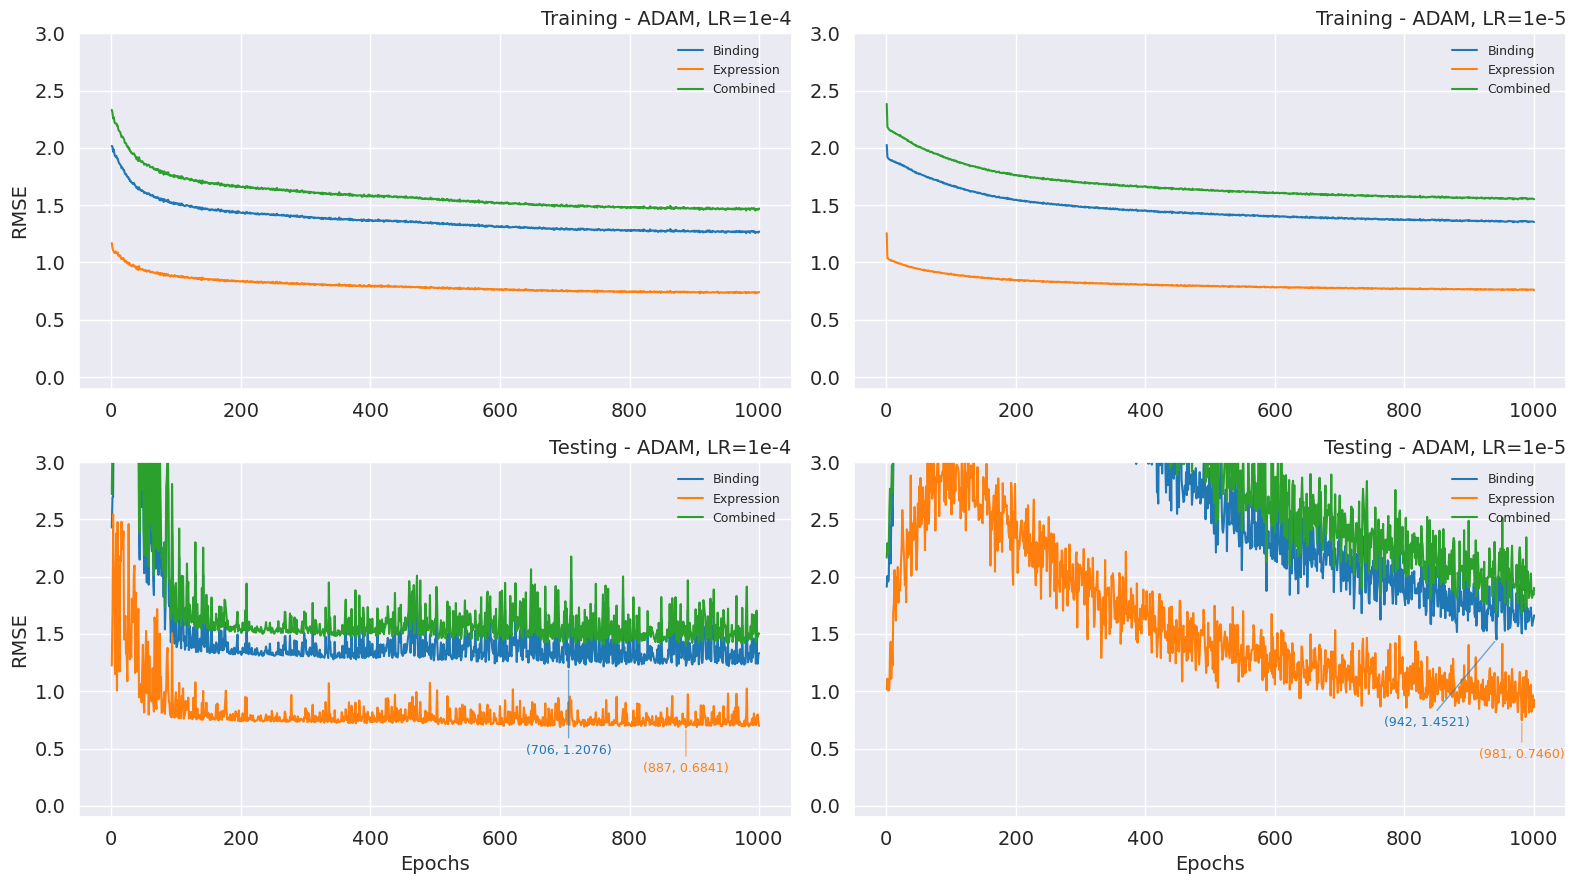

In [189]:
be_adam_lr_1e_neg_4 = "../../results/run_results/bert_BE/adam.lr1e-04.bert_BE-DMS_OLD-2025-01-03_22-49/bert_BE-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/bert_BE/adam.lr1e-05.bert_BE-DMS_OLD-2025-01-03_15-27/bert_BE-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_BE"
coords = {
    "B, ADAM, LR:1e-4": (0,-55),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (-50,-55),
    "E, ADAM, LR:1e-5": (0,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### BERT-BLSTM Initialized w/ BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 407, rmse 1.0088
	Expression: epoch 939, rmse 0.5604
- ADAM, LR=1e-5:
	Binding: epoch 999, rmse 1.1019
	Expression: epoch 909, rmse 0.5908


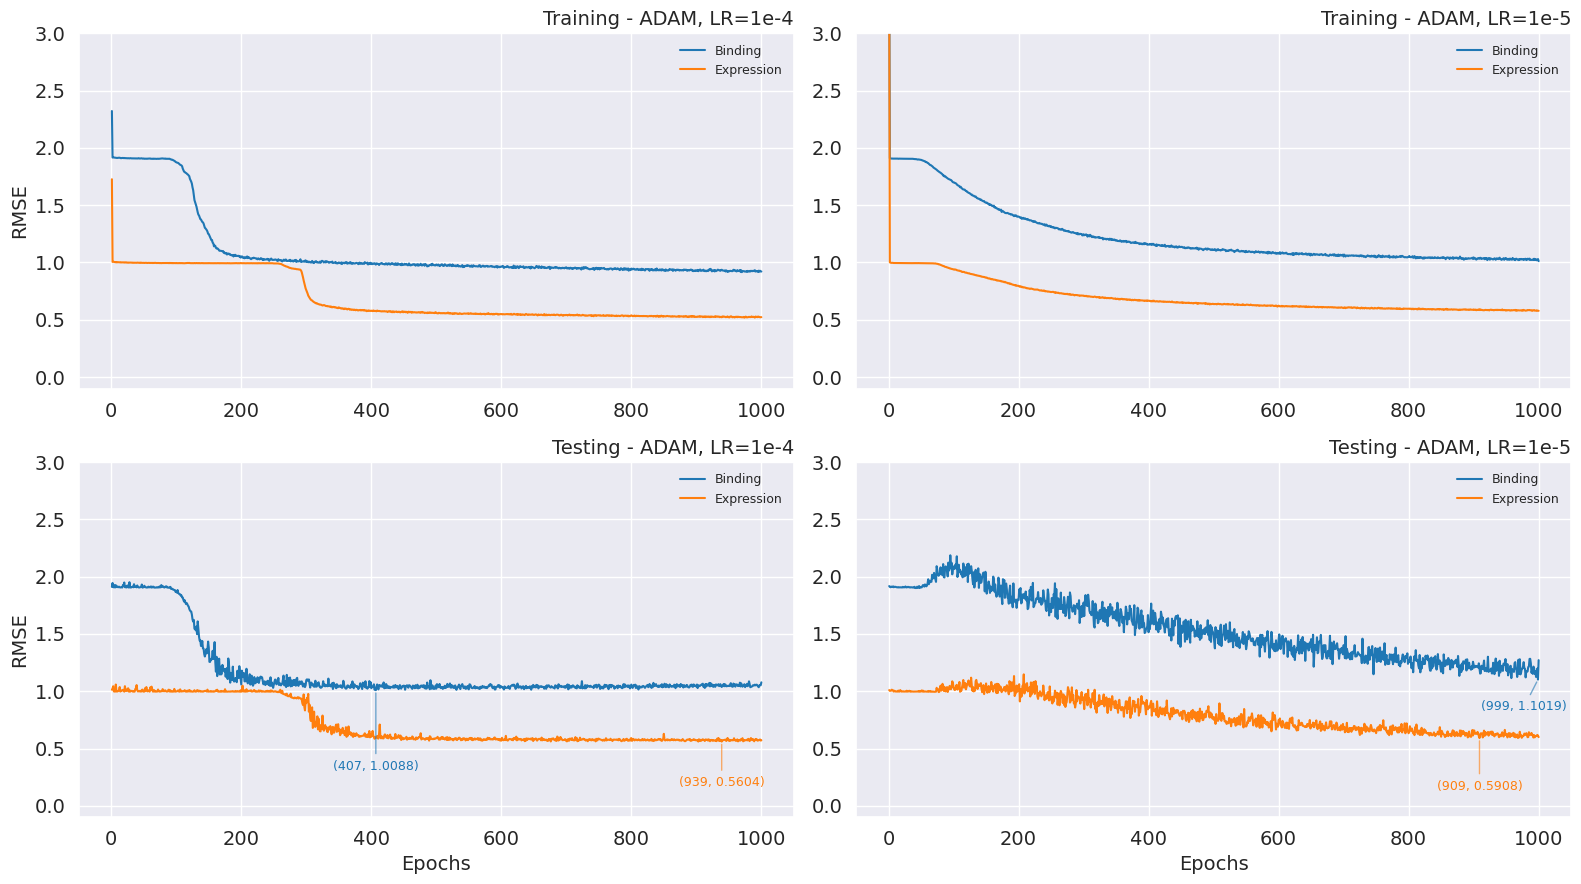

In [190]:
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm-DMS_OLD-binding-2024-12-07_02-56/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-05.bert_blstm-DMS_OLD-binding-2024-12-05_18-11/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm-DMS_OLD-expression-2024-12-07_02-58/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-05.bert_blstm-DMS_OLD-expression-2024-12-05_18-12/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_blstm"
coords = {
    "B, ADAM, LR:1e-4": (0,-50),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (-10,-15),
    "E, ADAM, LR:1e-5": (0,-30)
}
plot_comparative_lr_bert_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf", "BLSTM")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 694, rmse 1.0021
	Expression: epoch 917, rmse 0.5597
- ADAM, LR=1e-5:
	Binding: epoch 953, rmse 1.1157
	Expression: epoch 935, rmse 0.6162


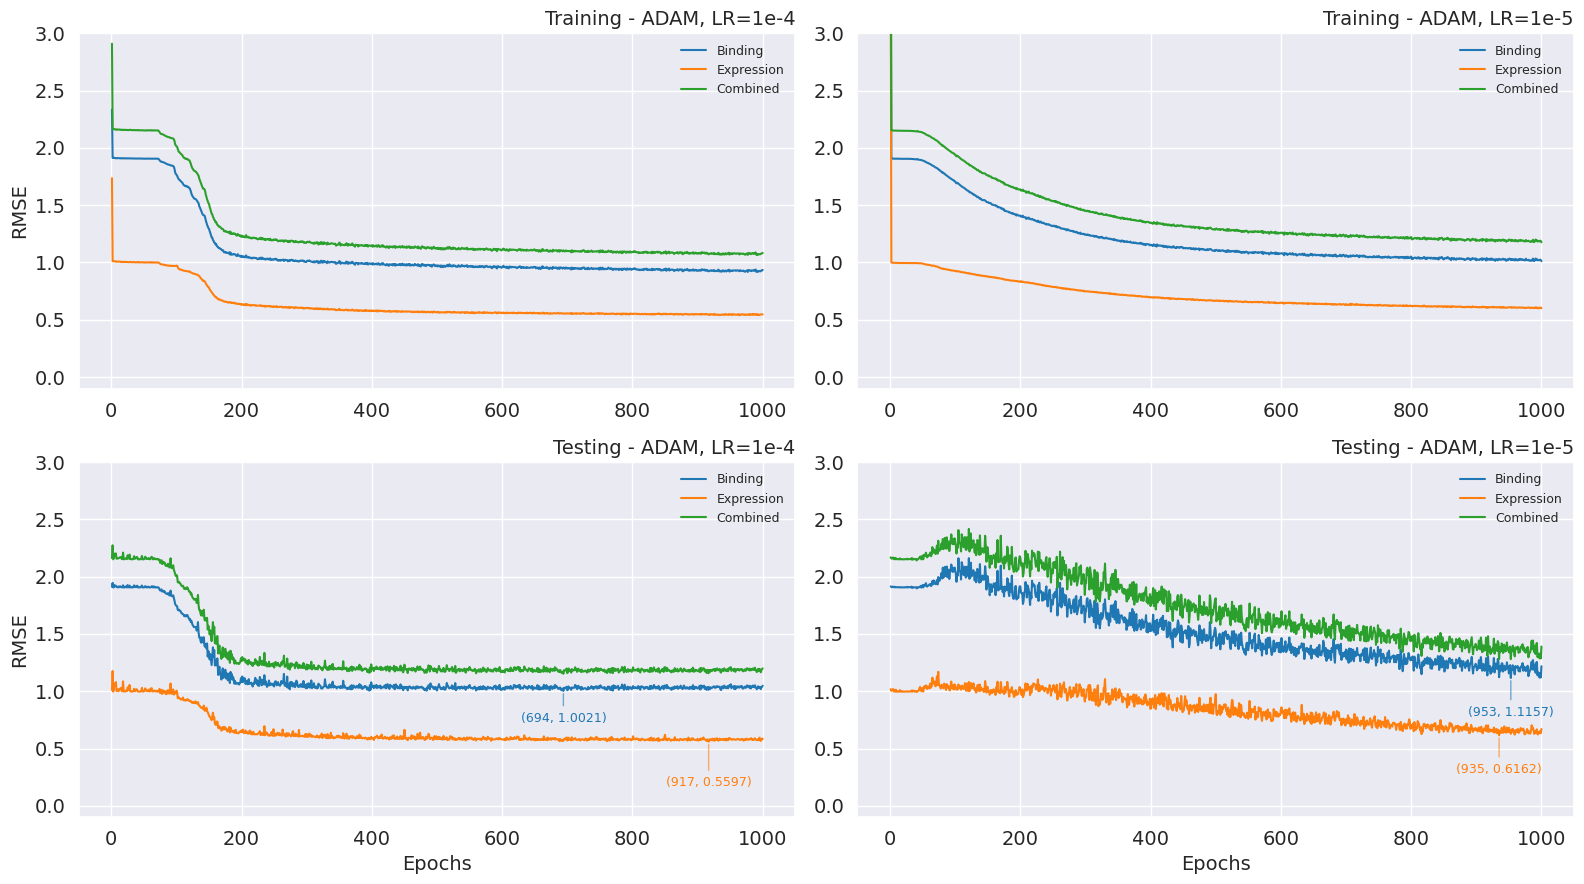

In [191]:
be_adam_lr_1e_neg_4 = "../../results/run_results/bert_blstm/adam.lr1e-04.bert_blstm_BE-DMS_OLD-2025-01-04_00-39/bert_blstm_BE-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/bert_blstm/adam.lr1e-05.bert_blstm_BE-DMS_OLD-2025-01-04_00-37/bert_blstm_BE-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_blstm_BE"
coords = {
    "B, ADAM, LR:1e-4": (0,-15),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-20),
    "E, ADAM, LR:1e-5": (0,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### BERT-GCN Initialized w/ BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 687, rmse 1.1326
	Expression: epoch 995, rmse 0.6230
- ADAM, LR=1e-5:
	Binding: epoch 6, rmse 1.9094
	Expression: epoch 16, rmse 1.0393


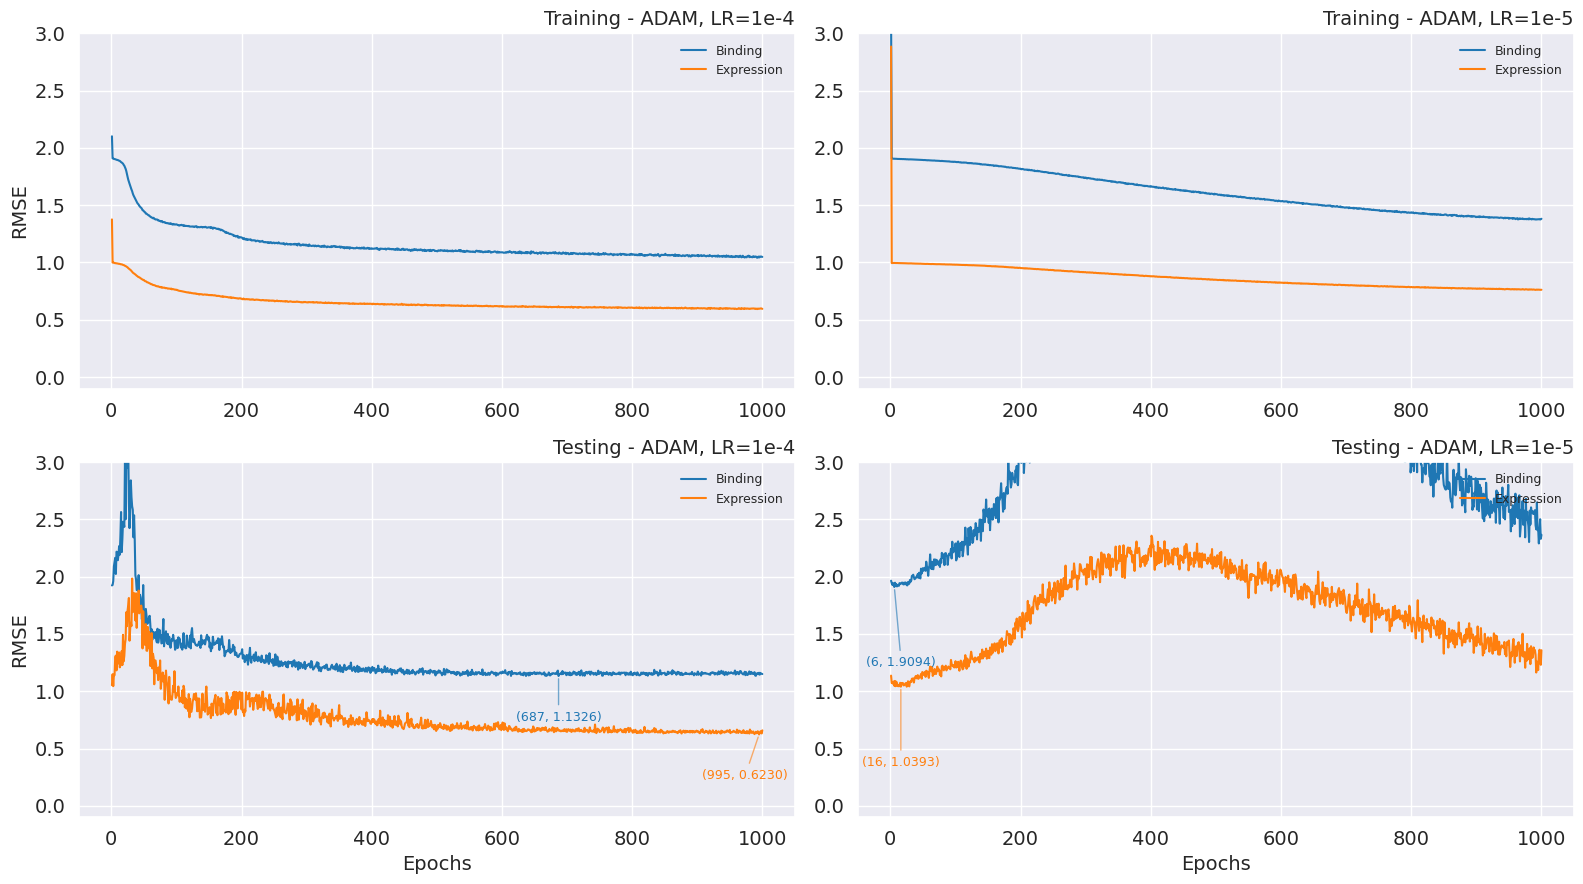

In [192]:
# OLD VERSION (no BE available)
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-binding-2024-12-05_17-52/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-binding-2024-12-05_17-49/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-expression-2024-12-05_17-51/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-expression-2024-12-05_17-50/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn.old"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (-10,-25),
    "B, ADAM, LR:1e-5": (5,-50),
    "E, ADAM, LR:1e-5": (0,-50)
}
plot_comparative_lr_bert_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf", "GCN")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 760, rmse 1.1318
	Expression: epoch 671, rmse 0.6237
- ADAM, LR=1e-5:
	Binding: epoch 955, rmse 1.3986
	Expression: epoch 995, rmse 0.6775


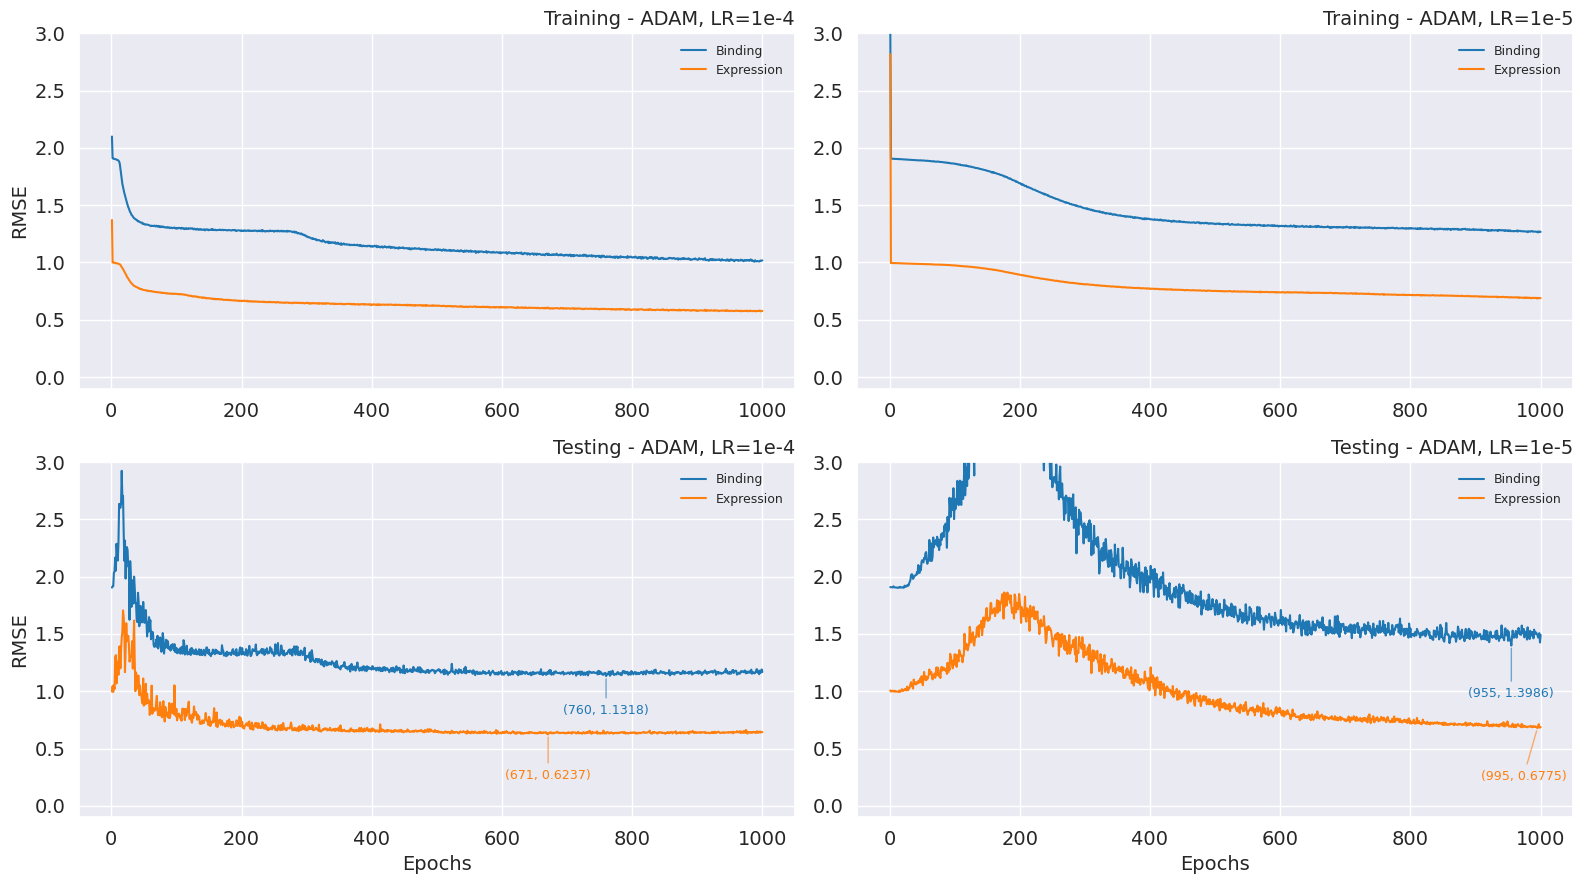

In [193]:
# NEW VERSION - double relu
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-binding-2025-01-04_00-28/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-binding-2025-01-03_23-00/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn-DMS_OLD-expression-2025-01-04_00-32/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn-DMS_OLD-expression-2025-01-03_20-46/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-20),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-30),
    "E, ADAM, LR:1e-5": (-10,-30)
}
plot_comparative_lr_bert_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf", "GCN")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 651, rmse 1.1164
	Expression: epoch 667, rmse 0.6219
- ADAM, LR=1e-5:
	Binding: epoch 955, rmse 1.3307
	Expression: epoch 953, rmse 0.8252


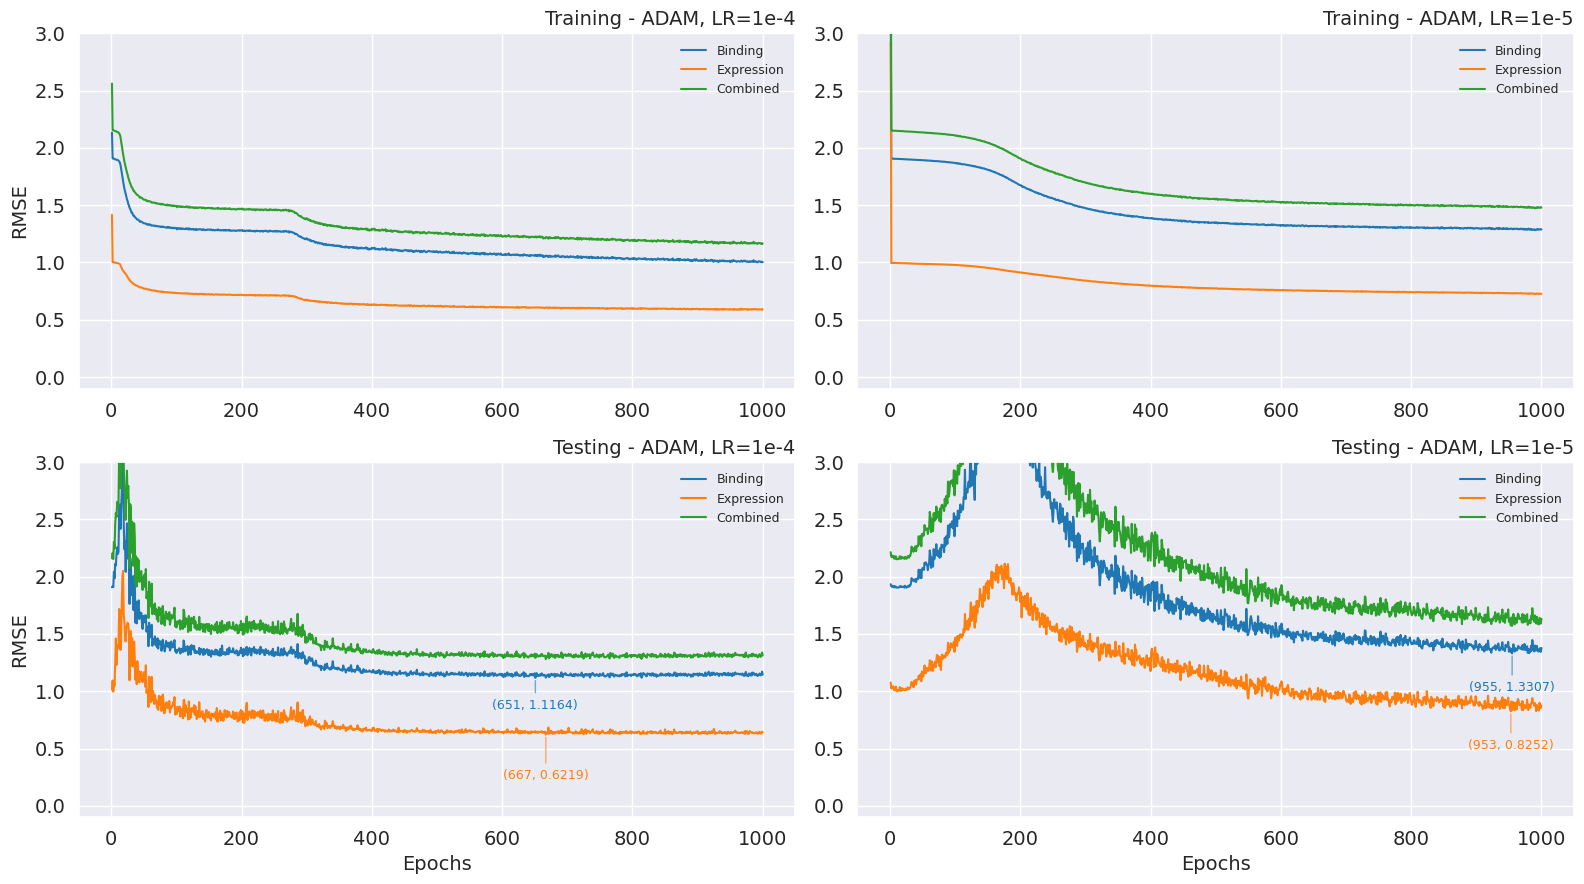

In [194]:
# NEW VERSION BE - double relu
be_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/adam.lr1e-04.bert_gcn_BE-DMS_OLD-2025-01-05_11-30/bert_gcn_BE-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/adam.lr1e-05.bert_gcn_BE-DMS_OLD-2025-01-05_00-22/bert_gcn_BE-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn_BE.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-15),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-20),
    "E, ADAM, LR:1e-5": (0,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 662, rmse 1.0998
	Expression: epoch 852, rmse 0.6124
- ADAM, LR=1e-5:
	Binding: epoch 999, rmse 1.4201
	Expression: epoch 850, rmse 0.7599


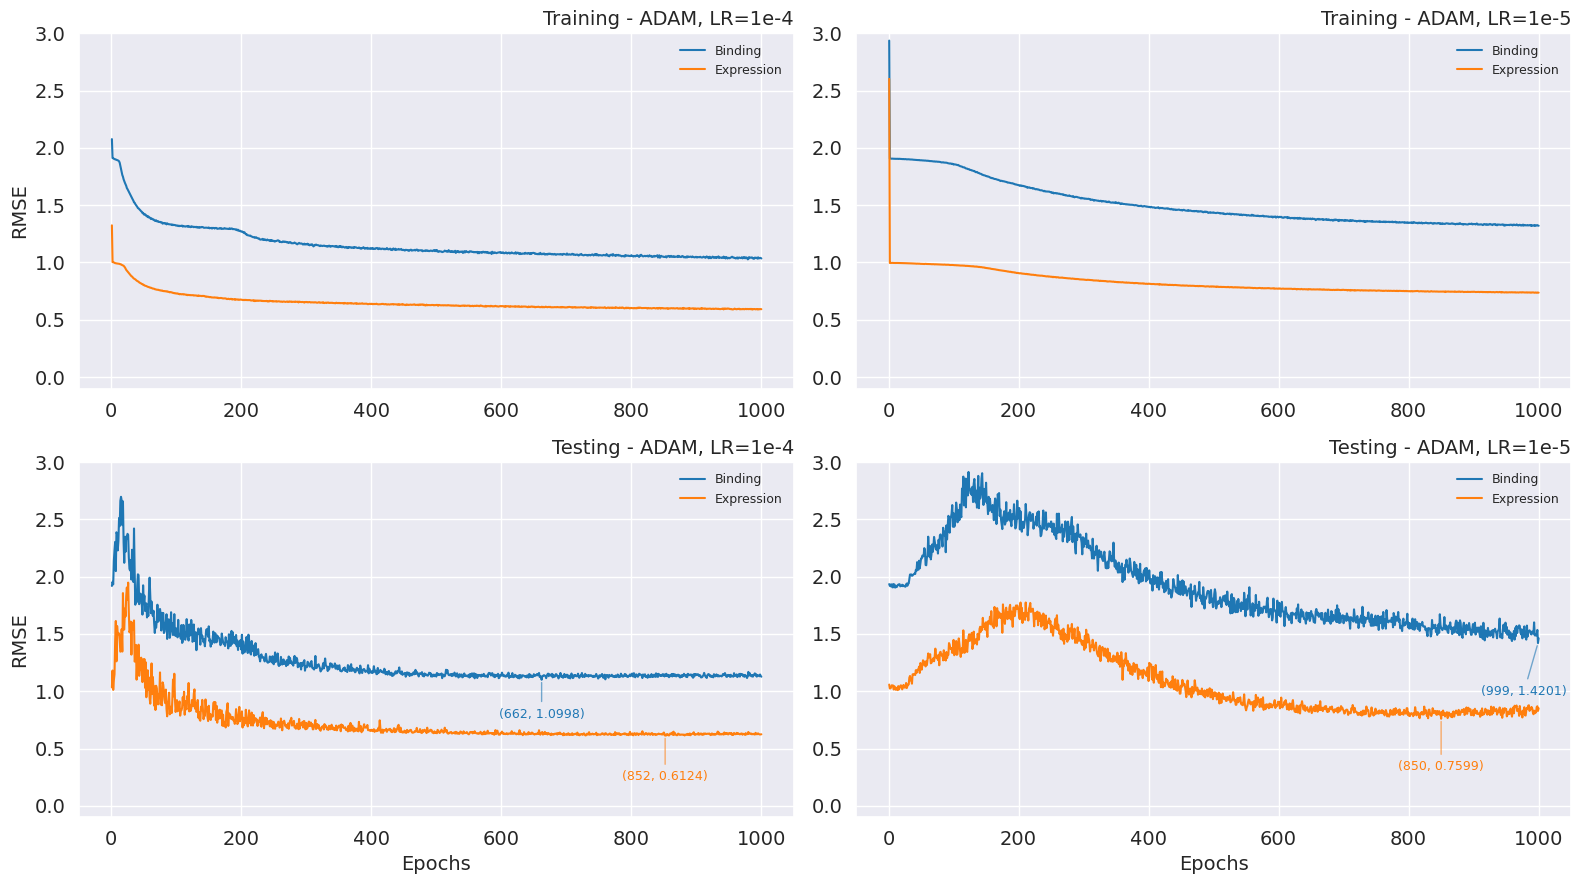

In [4]:
# NEW VERSION - single relu
b_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/single_relu-adam.lr1e-04.bert_gcn-DMS_OLD-binding-2025-01-10_03-33/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/single_relu-adam.lr1e-05.bert_gcn-DMS_OLD-binding-2025-01-10_03-30/bert_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/single_relu-adam.lr1e-04.bert_gcn-DMS_OLD-expression-2025-01-10_03-32/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/single_relu-adam.lr1e-05.bert_gcn-DMS_OLD-expression-2025-01-10_03-31/bert_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-20),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (-10,-30),
    "E, ADAM, LR:1e-5": (0,-30)
}
plot_comparative_lr_bert_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf", "GCN")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 922, rmse 1.1118
	Expression: epoch 926, rmse 0.6229
- ADAM, LR=1e-5:
	Binding: epoch 981, rmse 1.3947
	Expression: epoch 972, rmse 0.8445


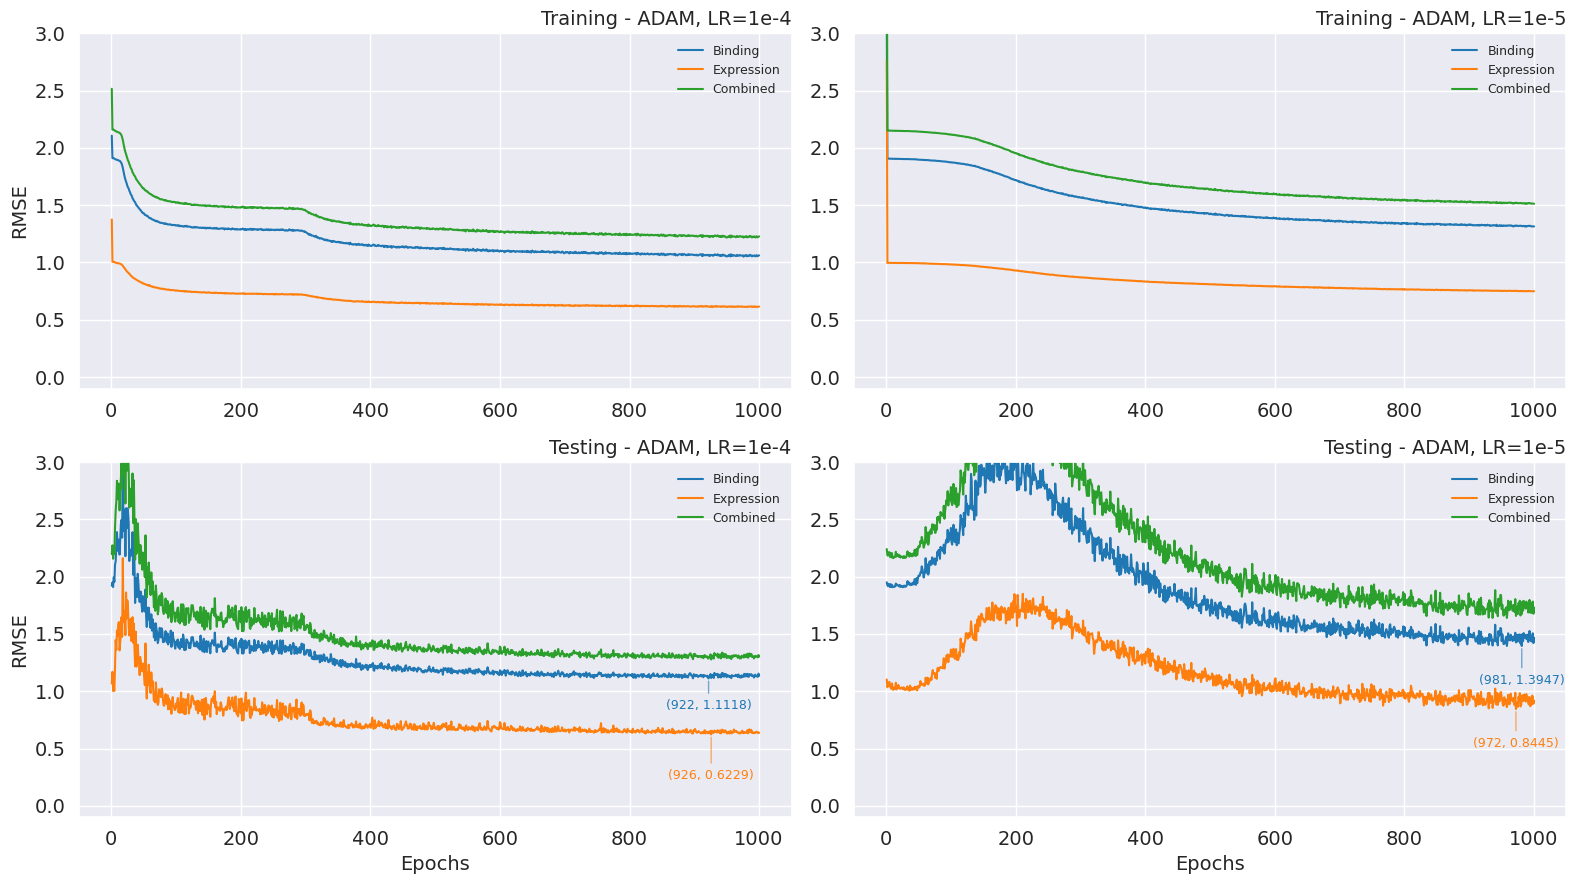

In [3]:
# NEW VERSION BE - single relu
be_adam_lr_1e_neg_4 = "../../results/run_results/bert_gcn/single_relu-adam.lr1e-04.bert_gcn_BE-DMS_OLD-2025-01-11_16-03/bert_gcn_BE-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/bert_gcn/single_relu-adam.lr1e-05.bert_gcn_BE-DMS_OLD-2025-01-10_03-46/bert_gcn_BE-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/bert_gcn_BE.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-15),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-20),
    "E, ADAM, LR:1e-5": (0,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

--- 
### ESM-FCN

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 76, rmse 0.5235
	Expression: epoch 233, rmse 0.3145
- ADAM, LR=1e-5:
	Binding: epoch 965, rmse 0.5185
	Expression: epoch 985, rmse 0.3172


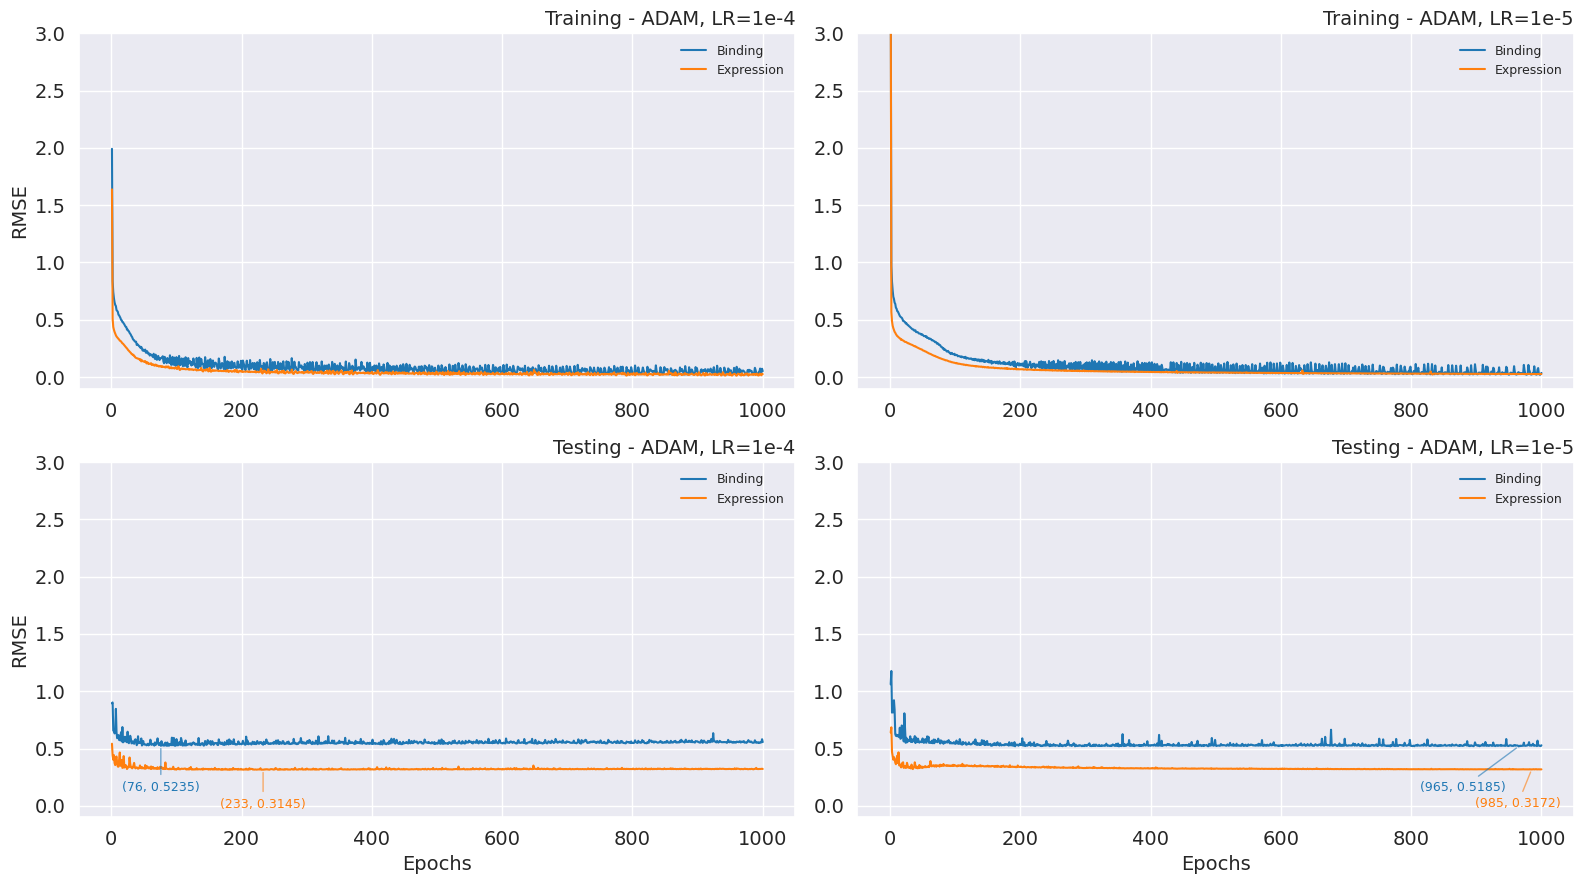

In [195]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-binding-2024-12-05_04-12/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-binding-2024-12-04_17-54/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn-DMS_OLD-expression-2024-12-05_04-15/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn-DMS_OLD-expression-2024-12-04_17-56/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_fcn"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-40,-25),
    "E, ADAM, LR:1e-5": (-10,-20)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 72, rmse 0.5005
	Expression: epoch 988, rmse 0.3102
- ADAM, LR=1e-5:
	Binding: epoch 868, rmse 0.5134
	Expression: epoch 989, rmse 0.3273


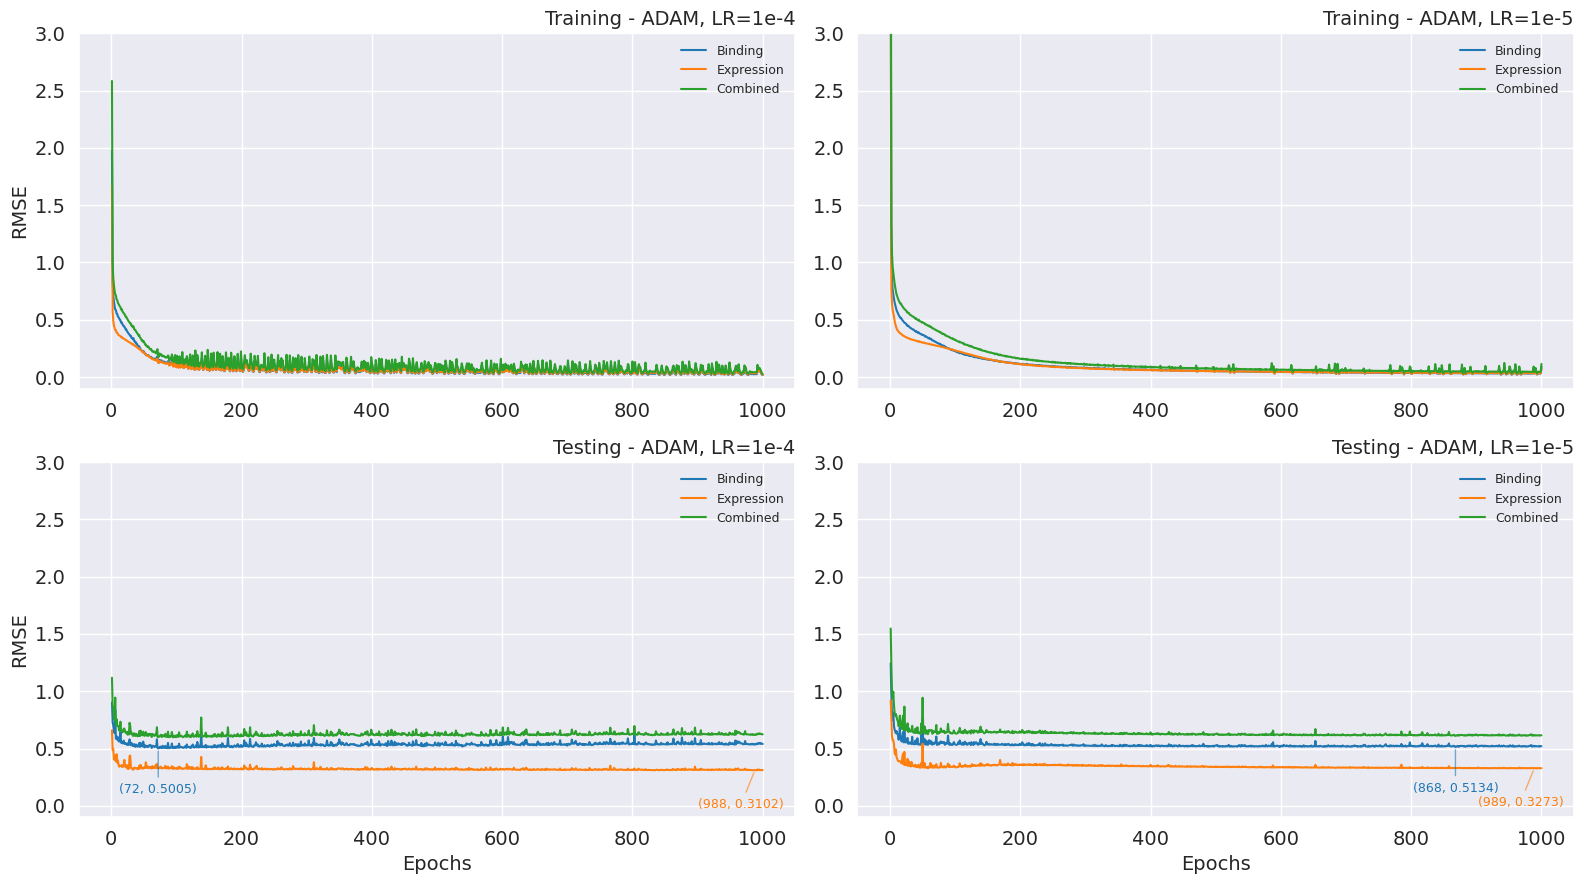

In [196]:
be_adam_lr_1e_neg_4 = "../../results/run_results/esm_fcn/adam.lr1e-04.esm_fcn_BE-DMS_OLD-2025-01-01_22-46/esm_fcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/esm_fcn/adam.lr1e-05.esm_fcn_BE-DMS_OLD-2025-01-01_22-45/esm_fcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_fcn_BE"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (-10,-20),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-5": (-10,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### ESM-GCN

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 109, rmse 0.5570
	Expression: epoch 189, rmse 0.3323
- ADAM, LR=1e-5:
	Binding: epoch 576, rmse 0.5347
	Expression: epoch 974, rmse 0.3213


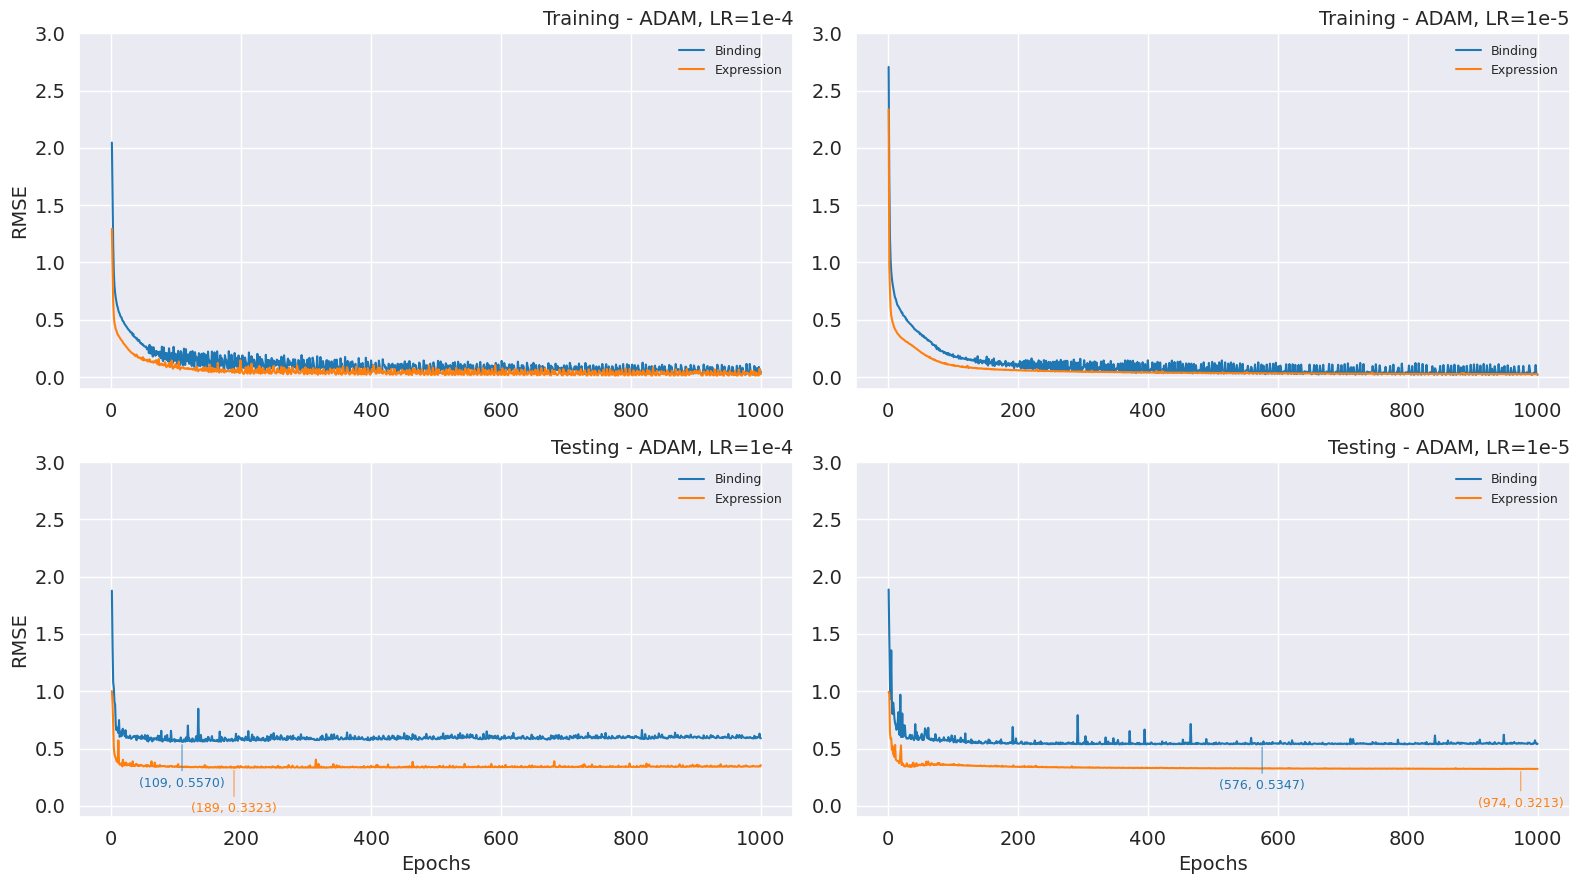

In [197]:
# OLD VERSION (no BE available)
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-binding-2024-12-09_00-32/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2024-12-07_09-12/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-expression-2024-12-09_00-31/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2024-12-07_09-13/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.old"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-5": (0,-20)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 115, rmse 0.5459
	Expression: epoch 188, rmse 0.3235
- ADAM, LR=1e-5:
	Binding: epoch 674, rmse 0.5201
	Expression: epoch 997, rmse 0.3184


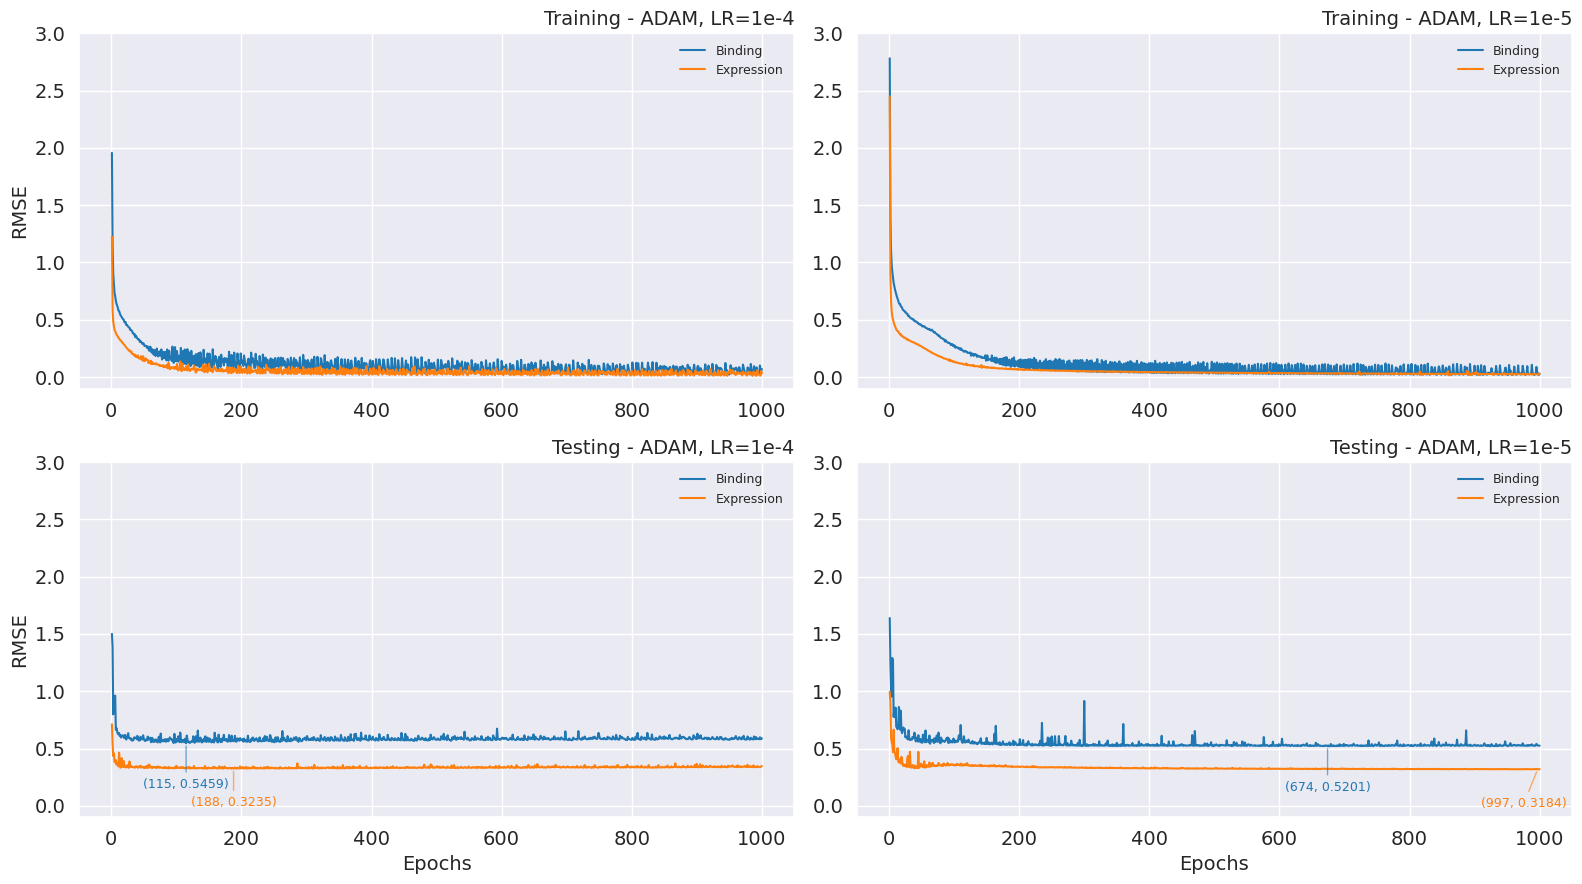

In [198]:
# NEW VERSION - double relu
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-binding-2025-01-07_20-54/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-07_20-53/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn-DMS_OLD-expression-2025-01-07_20-54/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-07_20-54/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-5": (-10,-20)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 175, rmse 0.5401
	Expression: epoch 982, rmse 0.3191
- ADAM, LR=1e-5:
	Binding: epoch 662, rmse 0.5348
	Expression: epoch 1000, rmse 0.3338


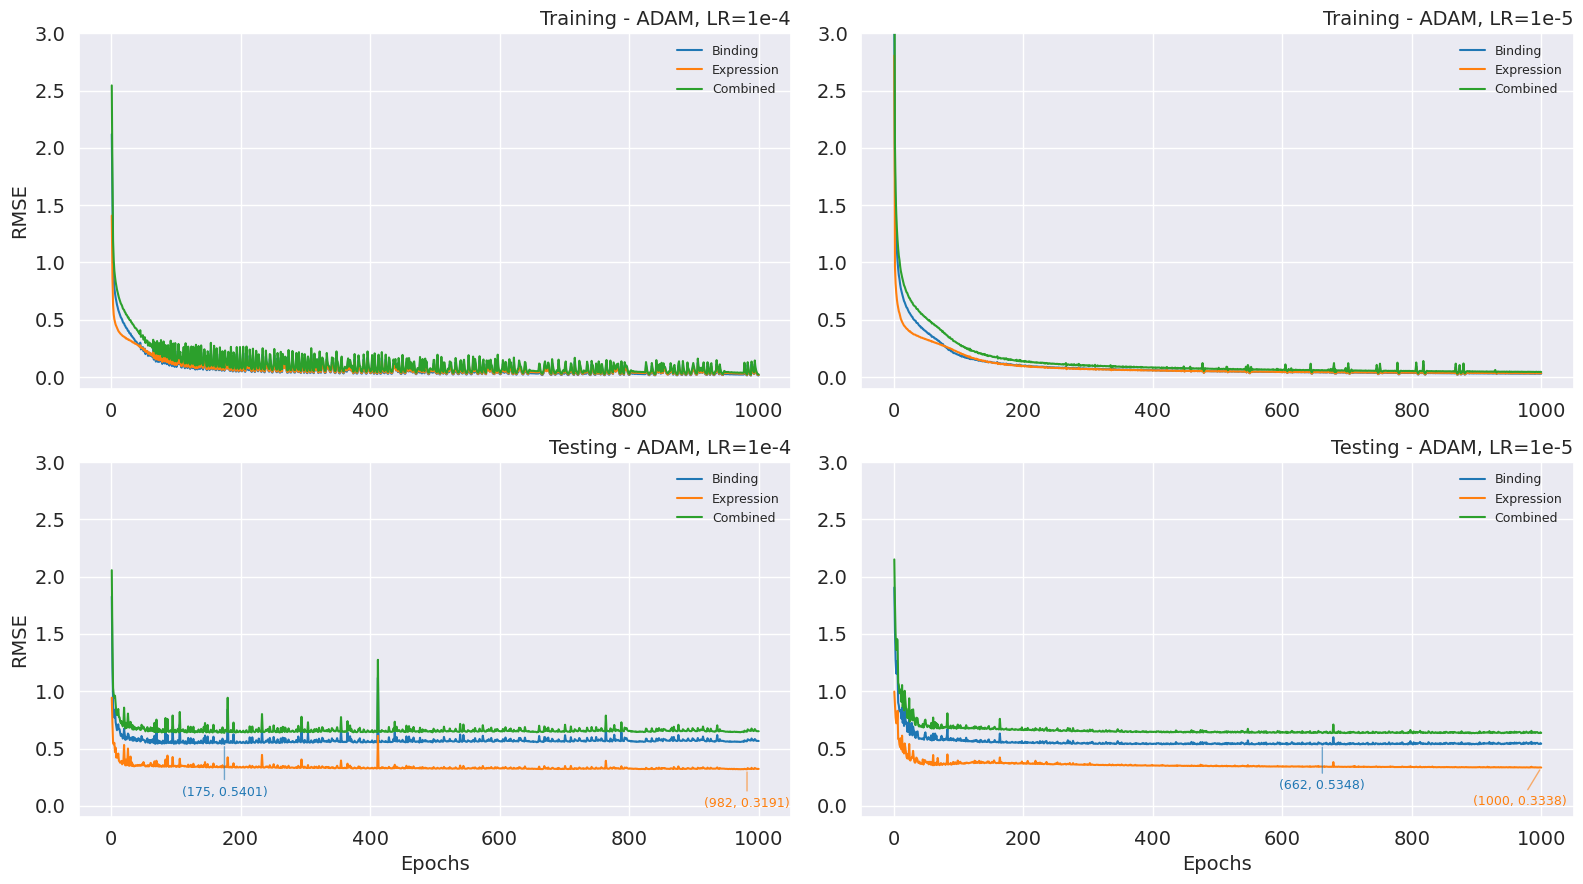

In [199]:
# NEW VERSION BE - double relu
be_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/adam.lr1e-04.esm_gcn_BE-DMS_OLD-2025-01-07_20-52/esm_gcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-07_20-52/esm_gcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn_BE.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-30),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-5": (-15,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 153, rmse 0.5435
	Expression: epoch 173, rmse 0.3203
- ADAM, LR=1e-5:
	Binding: epoch 731, rmse 0.5189
	Expression: epoch 993, rmse 0.3161


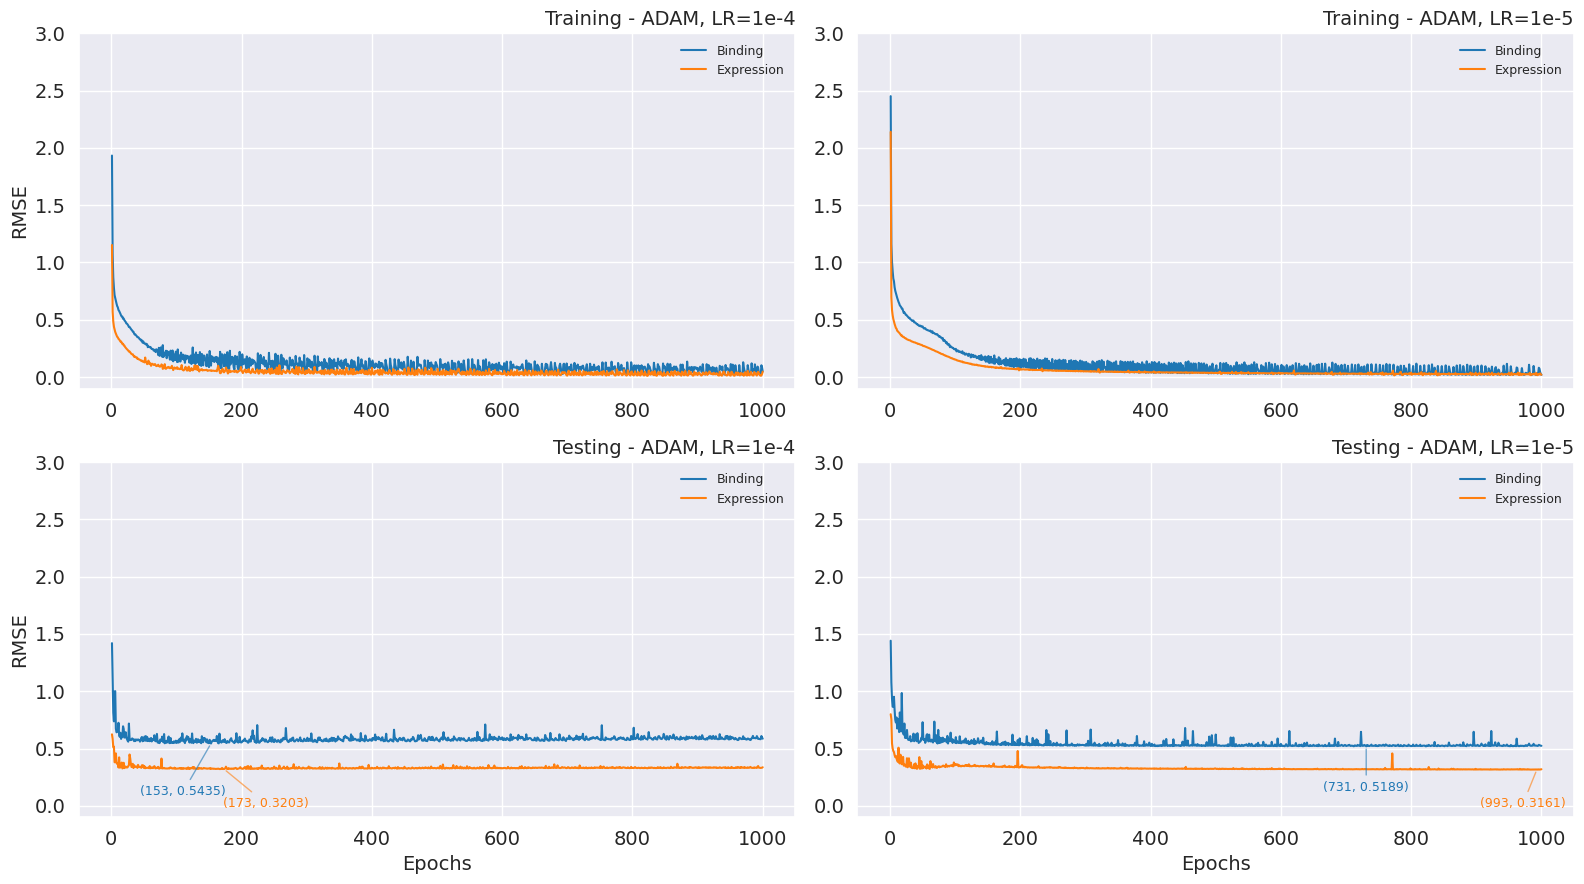

In [8]:
# NEW VERSION - single relu
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-04.esm_gcn-DMS_OLD-binding-2025-01-14_17-42/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-05.esm_gcn-DMS_OLD-binding-2025-01-12_05-51/esm_gcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-04.esm_gcn-DMS_OLD-expression-2025-01-12_05-54/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-05.esm_gcn-DMS_OLD-expression-2025-01-12_05-52/esm_gcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn.1relu"
coords = {
    "B, ADAM, LR:1e-4": (-20,-30),
    "E, ADAM, LR:1e-4": (30,-20),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-5": (-10,-20)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 62, rmse 0.5290
	Expression: epoch 591, rmse 0.3180
- ADAM, LR=1e-5:
	Binding: epoch 945, rmse 0.5117
	Expression: epoch 962, rmse 0.3218


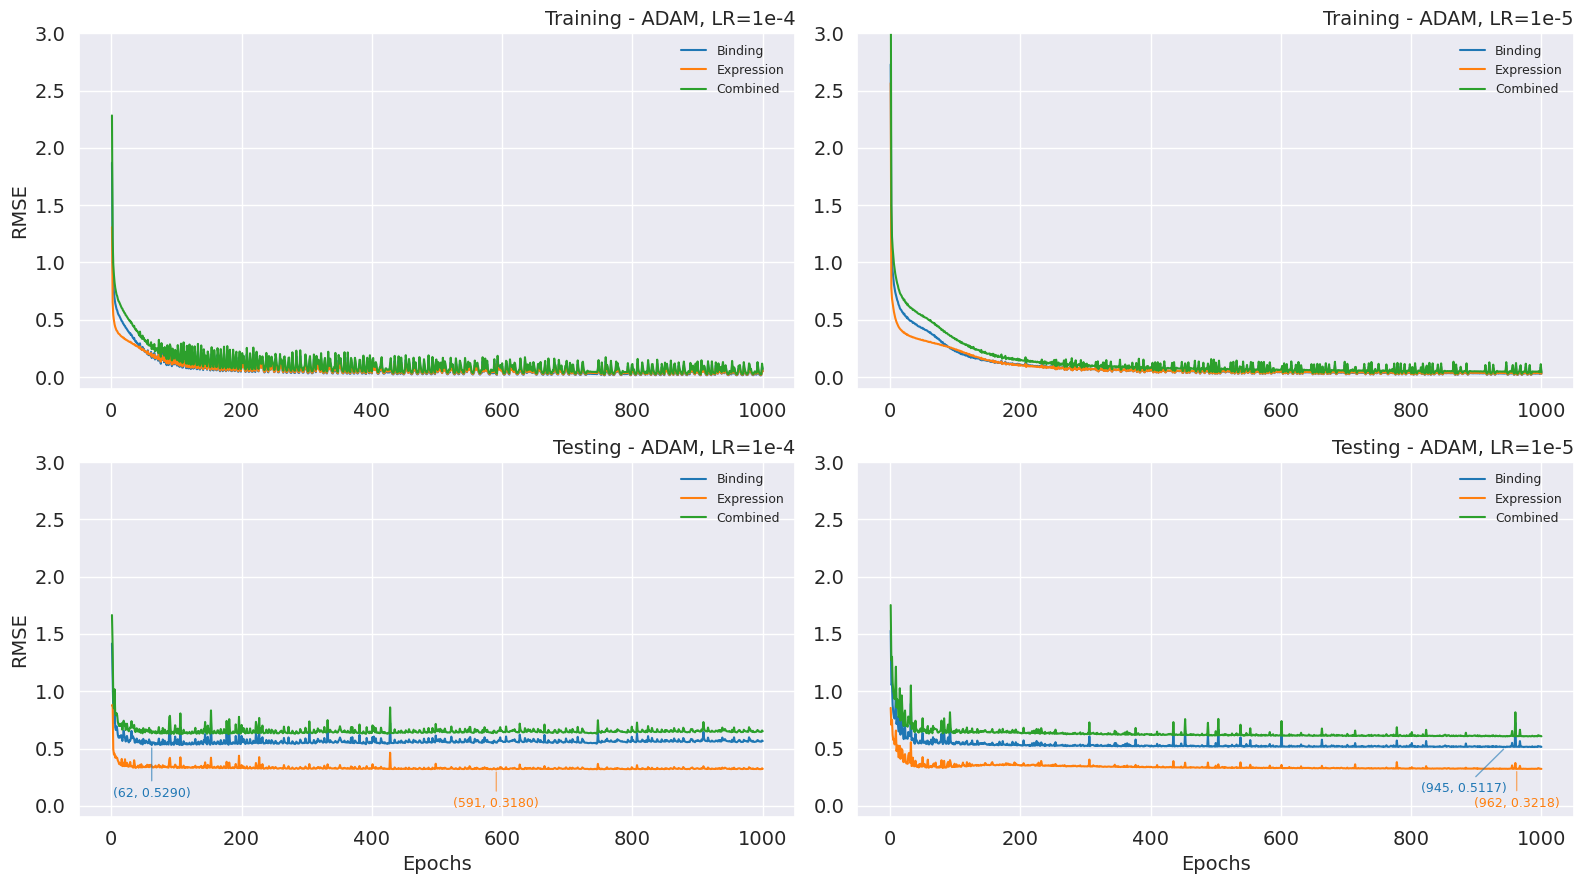

In [7]:
# NEW VERSION BE - single relu
be_adam_lr_1e_neg_4 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-04.esm_gcn_BE-DMS_OLD-2025-01-11_16-07/esm_gcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/esm_gcn/single_relu-adam.lr1e-05.esm_gcn_BE-DMS_OLD-2025-01-11_16-06/esm_gcn_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_gcn_BE.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-30),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-30,-25),
    "E, ADAM, LR:1e-5": (0,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

--- 
### ESM-BLSTM

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 99, rmse 0.5362
	Expression: epoch 233, rmse 0.3227
- ADAM, LR=1e-5:
	Binding: epoch 329, rmse 0.5242
	Expression: epoch 907, rmse 0.3202


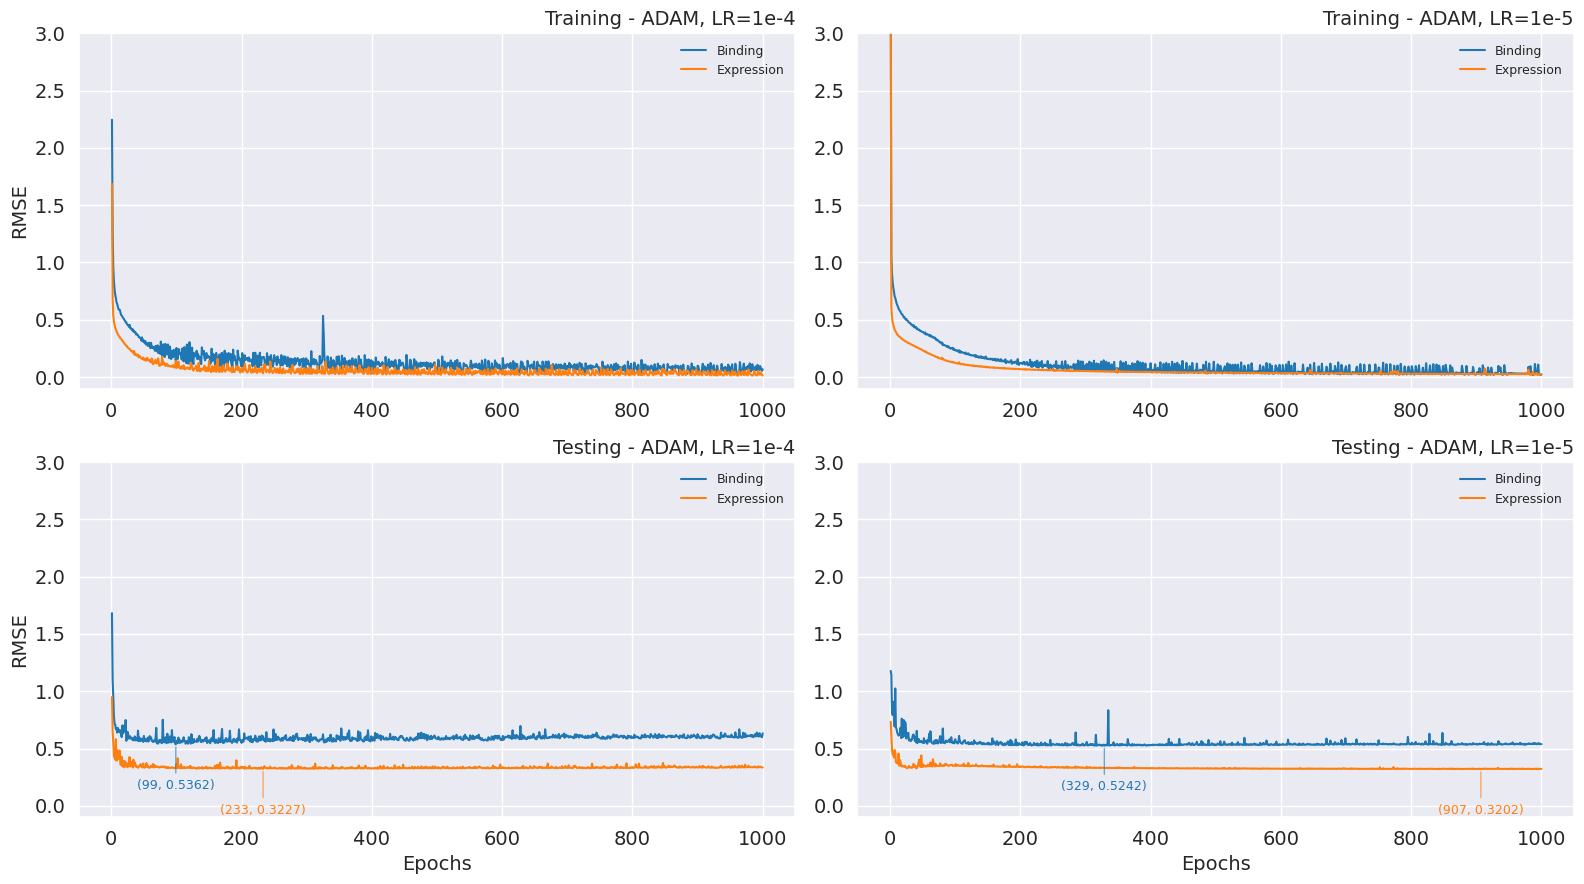

In [200]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-04.esm_blstm-DMS_OLD-binding-2024-12-17_10-42/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm-DMS_OLD-binding-2024-12-07_08-58/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-04.esm_blstm-DMS_OLD-expression-2024-12-17_10-43/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm-DMS_OLD-expression-2024-12-07_09-00/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-5": (0,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 89, rmse 0.5257
	Expression: epoch 522, rmse 0.3241
- ADAM, LR=1e-5:
	Binding: epoch 307, rmse 0.5218
	Expression: epoch 1000, rmse 0.3232


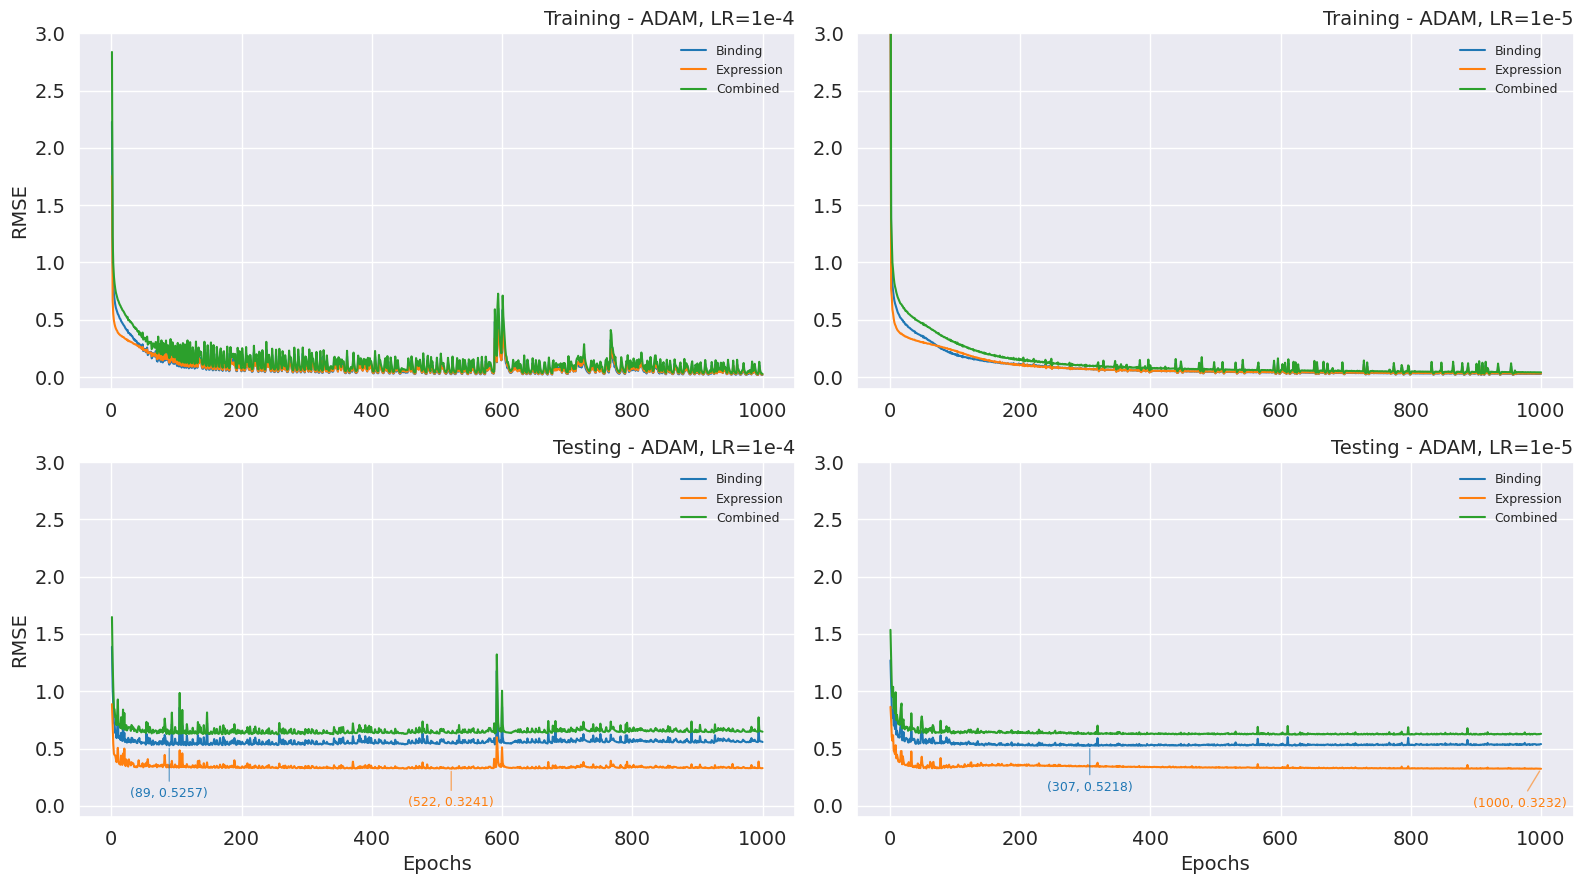

In [201]:
be_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm/adam.lr1e-04.esm_blstm_BE-DMS_OLD-2025-01-01_22-47/esm_blstm_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm/adam.lr1e-05.esm_blstm_BE-DMS_OLD-2025-01-01_22-47/esm_blstm_BE-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm_BE"
coords = {
    "B, ADAM, LR:1e-4": (0,-30),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-5": (-15,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### ESM-BLSTM Initialized w/ BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 119, rmse 0.5954
	Expression: epoch 211, rmse 0.3383
- ADAM, LR=1e-5:
	Binding: epoch 447, rmse 0.6573
	Expression: epoch 952, rmse 0.3486


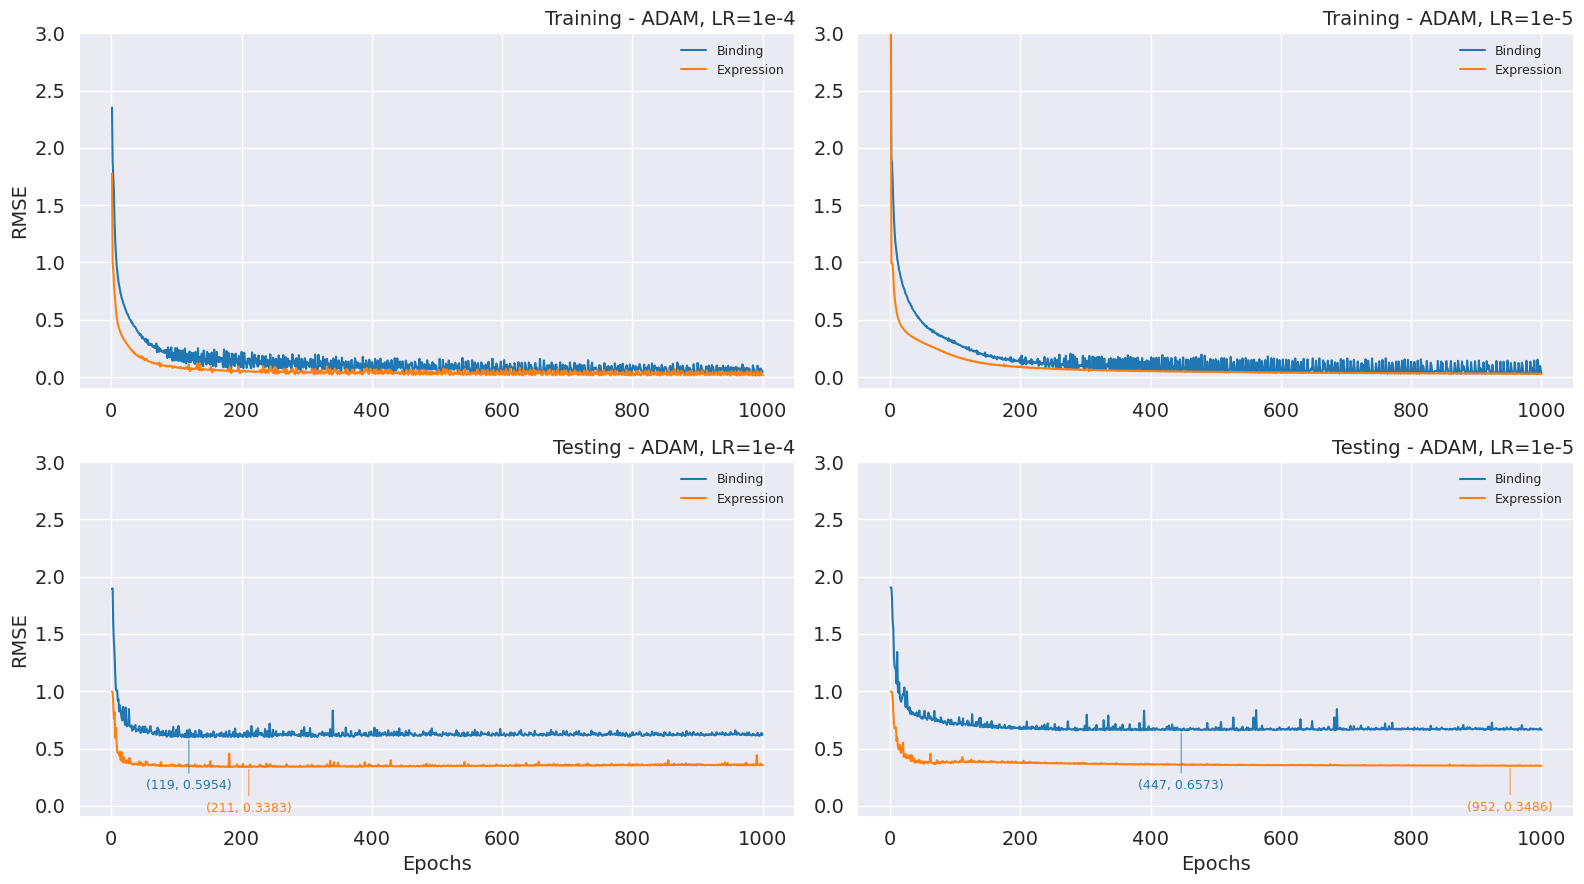

In [202]:
b_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-12-07_09-28/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-05.esm_blstm-bert_mlm_esm_init-DMS_OLD-binding-2024-12-07_09-02/esm_blstm-bert_mlm_esm_init-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-12-07_09-36/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-05.esm_blstm-bert_mlm_esm_init-DMS_OLD-expression-2024-12-07_09-18/esm_blstm-bert_mlm_esm_init-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm-bert_mlm_esm_init"
coords = {
    "B, ADAM, LR:1e-4": (0,-30),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (0,-35),
    "E, ADAM, LR:1e-5": (0,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 63, rmse 0.5697
	Expression: epoch 610, rmse 0.3415
- ADAM, LR=1e-5:
	Binding: epoch 633, rmse 0.5840
	Expression: epoch 995, rmse 0.3561


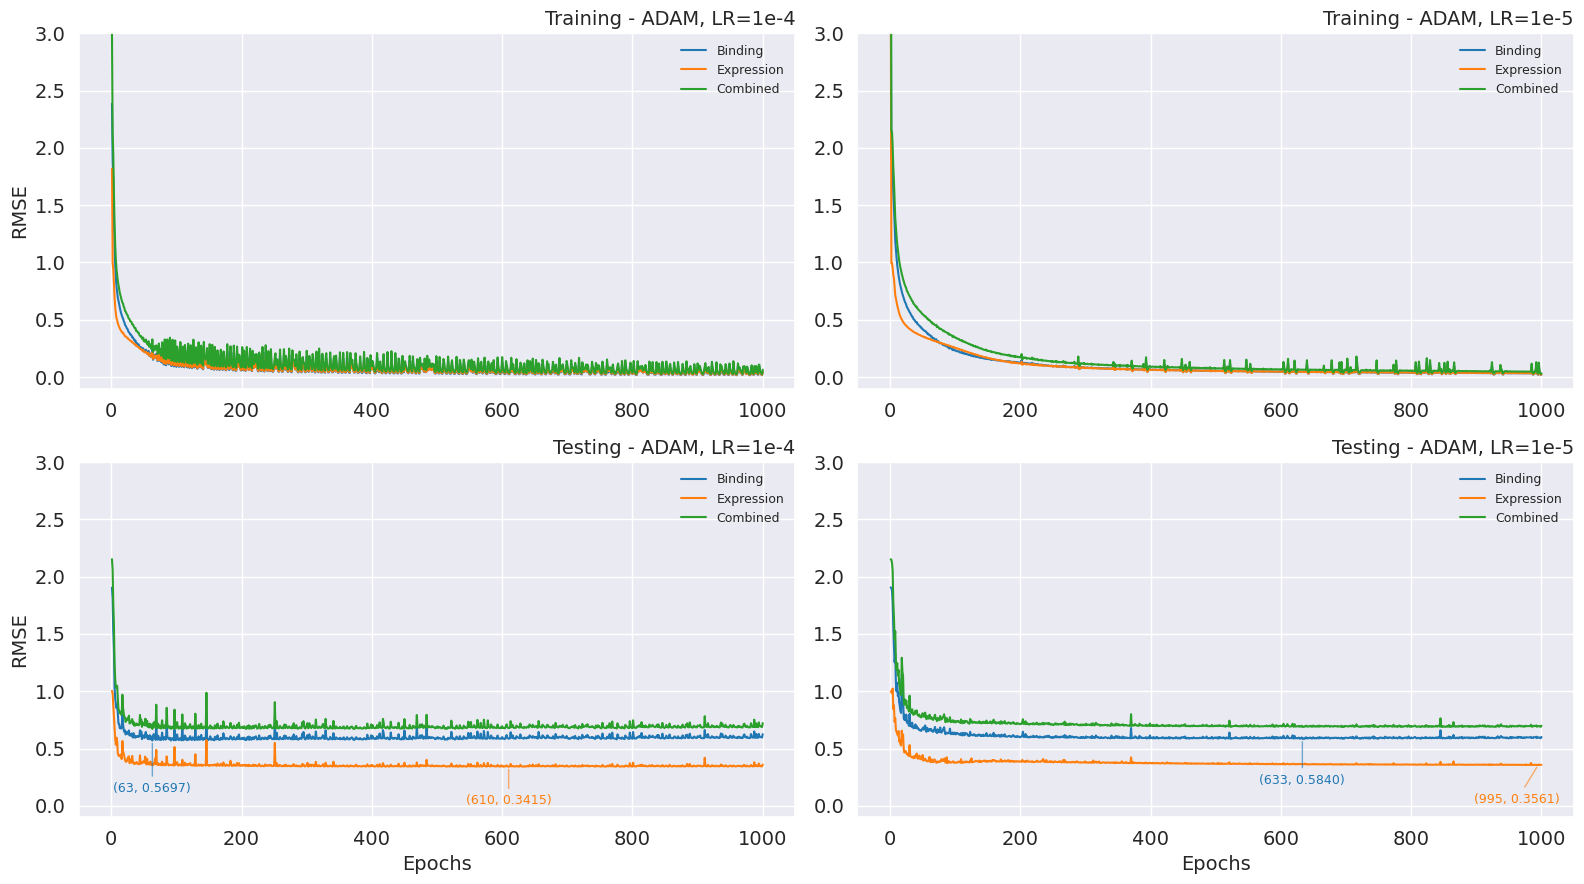

In [203]:
be_adam_lr_1e_neg_4 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-04.esm_blstm_BE-bert_mlm_esm_init-DMS_OLD-2025-01-01_22-48/esm_blstm_BE-bert_mlm_esm_init-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/esm_blstm-bert_mlm_esm_init/adam.lr1e-05.esm_blstm_BE-bert_mlm_esm_init-DMS_OLD-2025-01-01_22-48/esm_blstm_BE-bert_mlm_esm_init-DMS_OLD_BE-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/esm_blstm_BE-bert_mlm_esm_init"
coords = {
    "B, ADAM, LR:1e-4": (0,-30),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (0,-25),
    "E, ADAM, LR:1e-5": (-15,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### FCN ESM-CLS Preembedded

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 271, rmse 1.2743
	Expression: epoch 397, rmse 0.6534
- ADAM, LR=1e-5:
	Binding: epoch 987, rmse 1.2238
	Expression: epoch 1000, rmse 0.6107


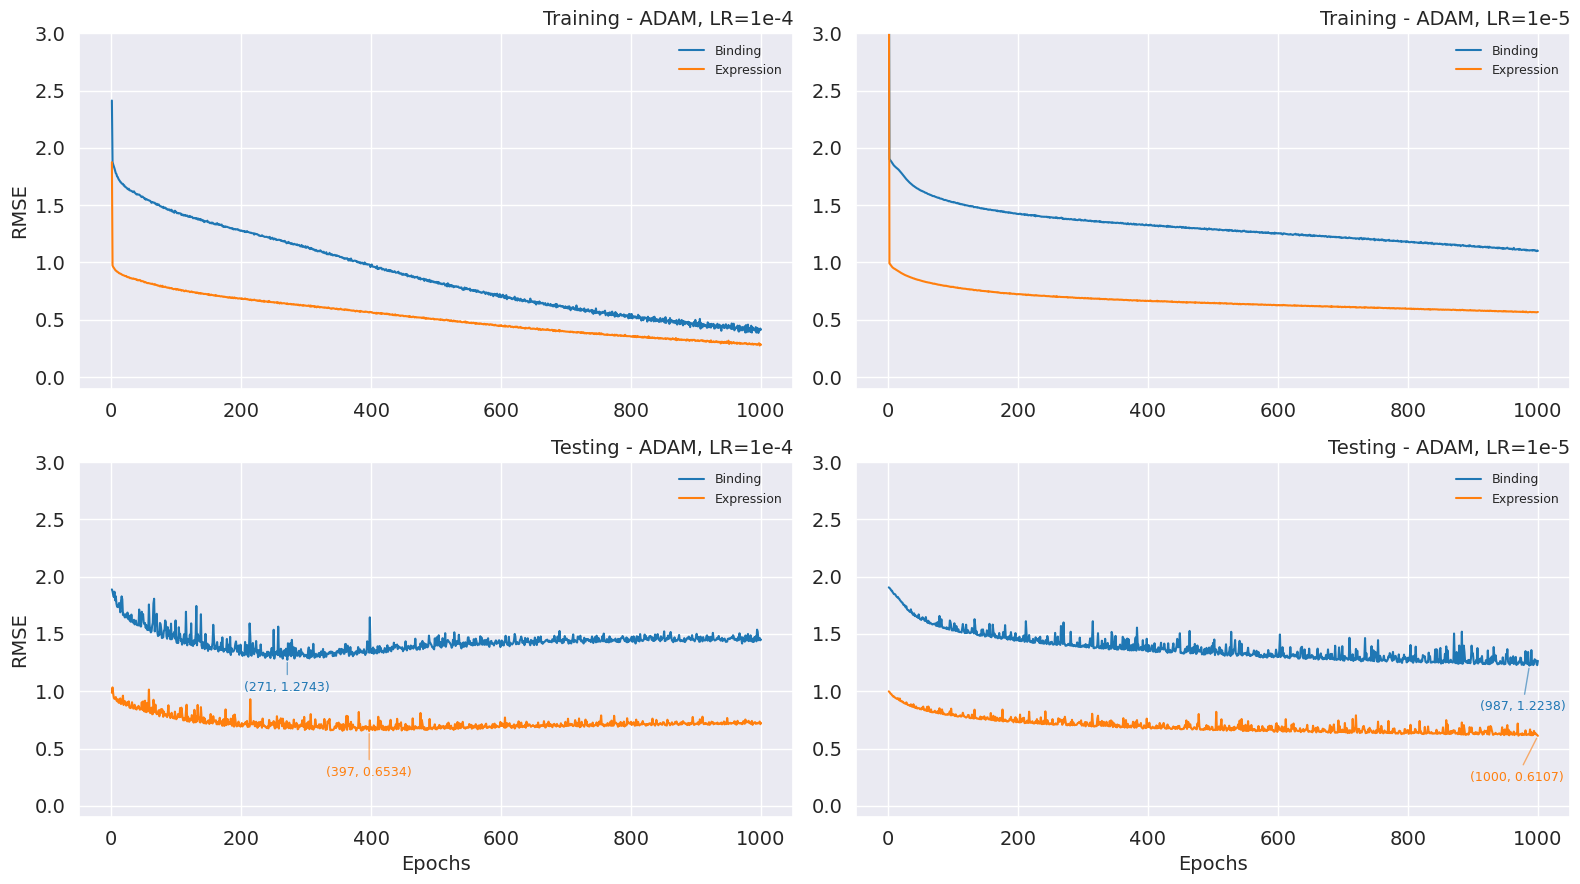

In [204]:
b_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-04.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-12-04_16-15/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-12-04_18-51/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-04.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-12-04_17-26/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-12-04_17-28/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/fcn-esm_cls_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-15),
    "E, ADAM, LR:1e-4": (0,-25),
    "B, ADAM, LR:1e-5": (-5,-25),
    "E, ADAM, LR:1e-5": (-15,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 301, rmse 1.2659
	Expression: epoch 392, rmse 0.6592
- ADAM, LR=1e-5:
	Binding: epoch 994, rmse 1.2239
	Expression: epoch 987, rmse 0.6514


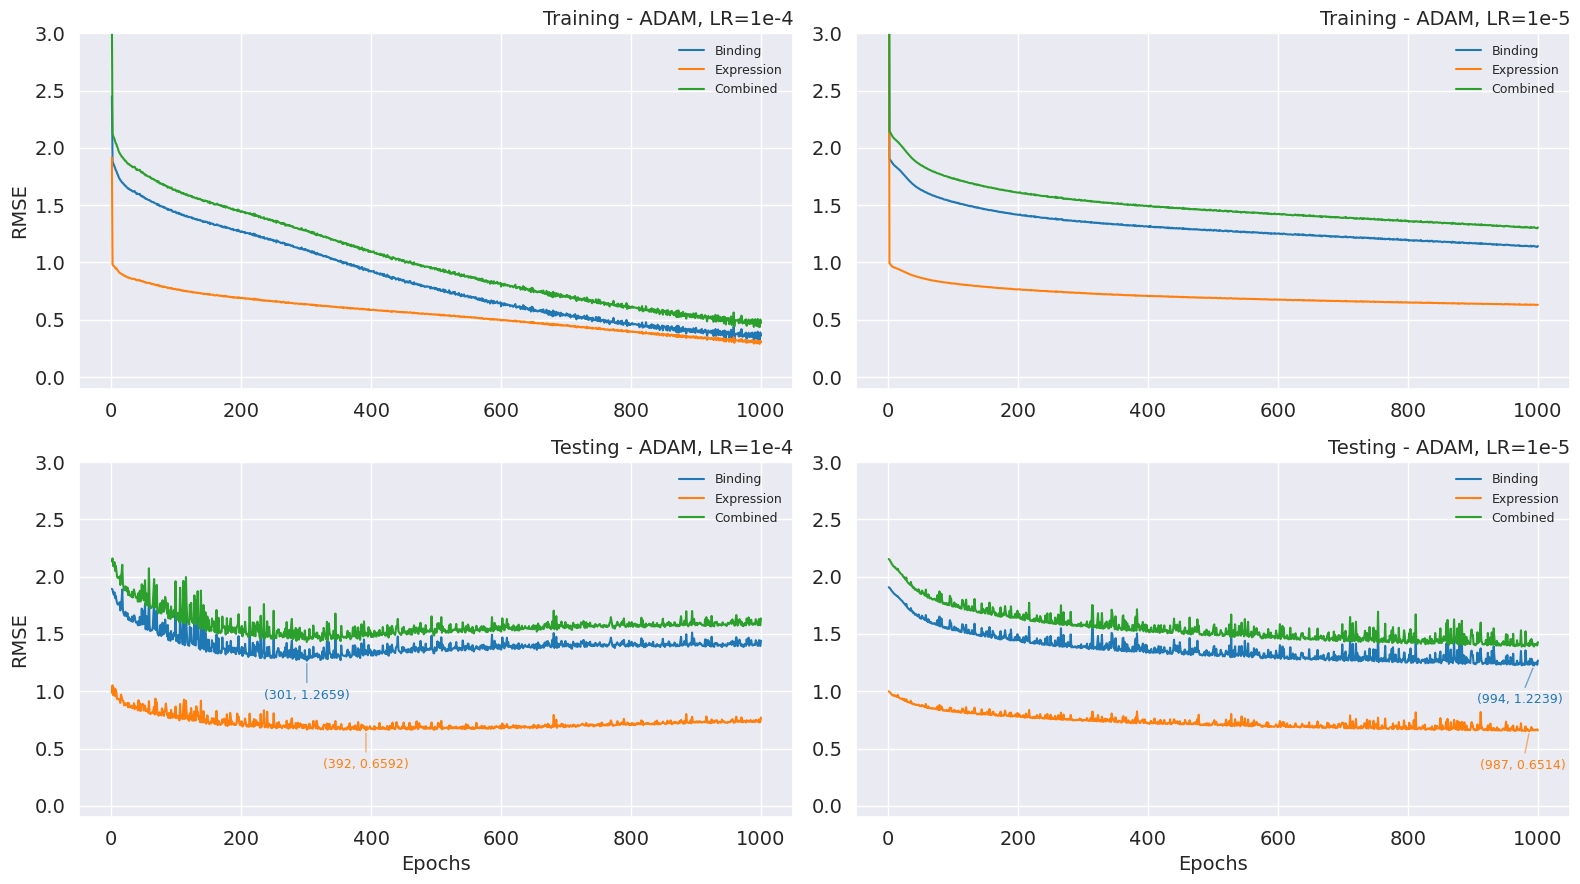

In [205]:
be_adam_lr_1e_neg_4 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-04.fcn_BE-ESM_CLS_preembedded-DMS_OLD-2025-01-01_19-22/fcn_BE-ESM_CLS_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/fcn-ESM_CLS_preembedded/adam.lr1e-05.fcn_BE-ESM_CLS_preembedded-DMS_OLD-2025-01-01_19-19/fcn_BE-ESM_CLS_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/fcn_BE-esm_cls_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-20),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-10,-20),
    "E, ADAM, LR:1e-5": (-5,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### BLSTM ESM-AA Preembedded

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 547, rmse 0.5518
	Expression: epoch 193, rmse 0.3335
- ADAM, LR=1e-5:
	Binding: epoch 971, rmse 0.5891
	Expression: epoch 946, rmse 0.3555


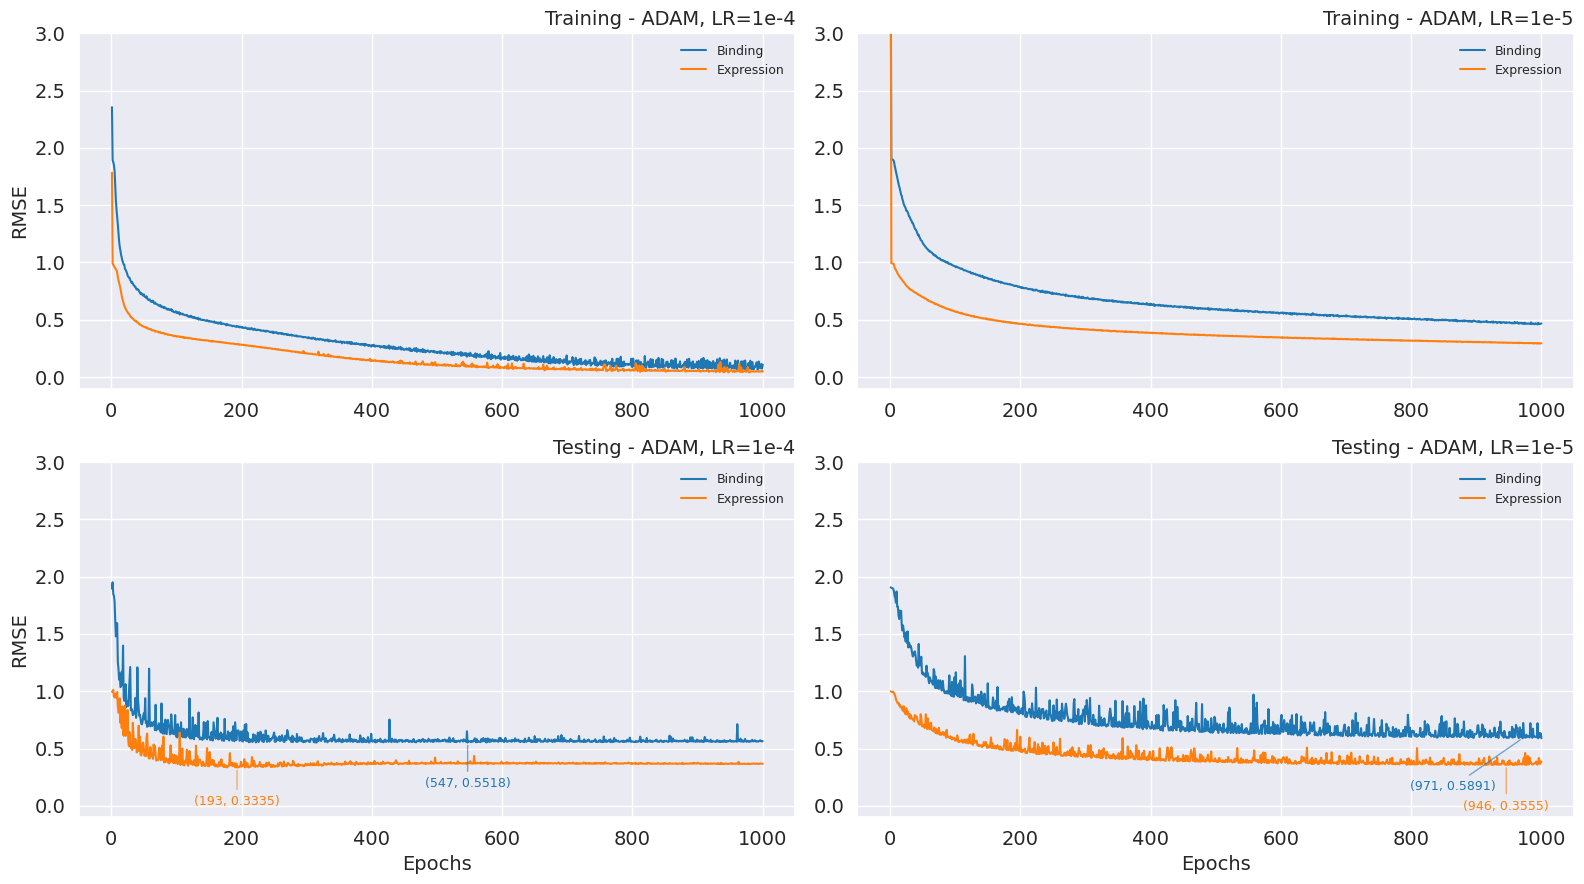

In [206]:
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-12-05_01-05/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-05.blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-12-04_14-58/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-12-05_01-06/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-05.blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-12-04_15-00/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-esm_aa_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-50,-30),
    "E, ADAM, LR:1e-5": (0,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 430, rmse 0.5396
	Expression: epoch 311, rmse 0.3454
- ADAM, LR=1e-5:
	Binding: epoch 964, rmse 0.5908
	Expression: epoch 984, rmse 0.3766


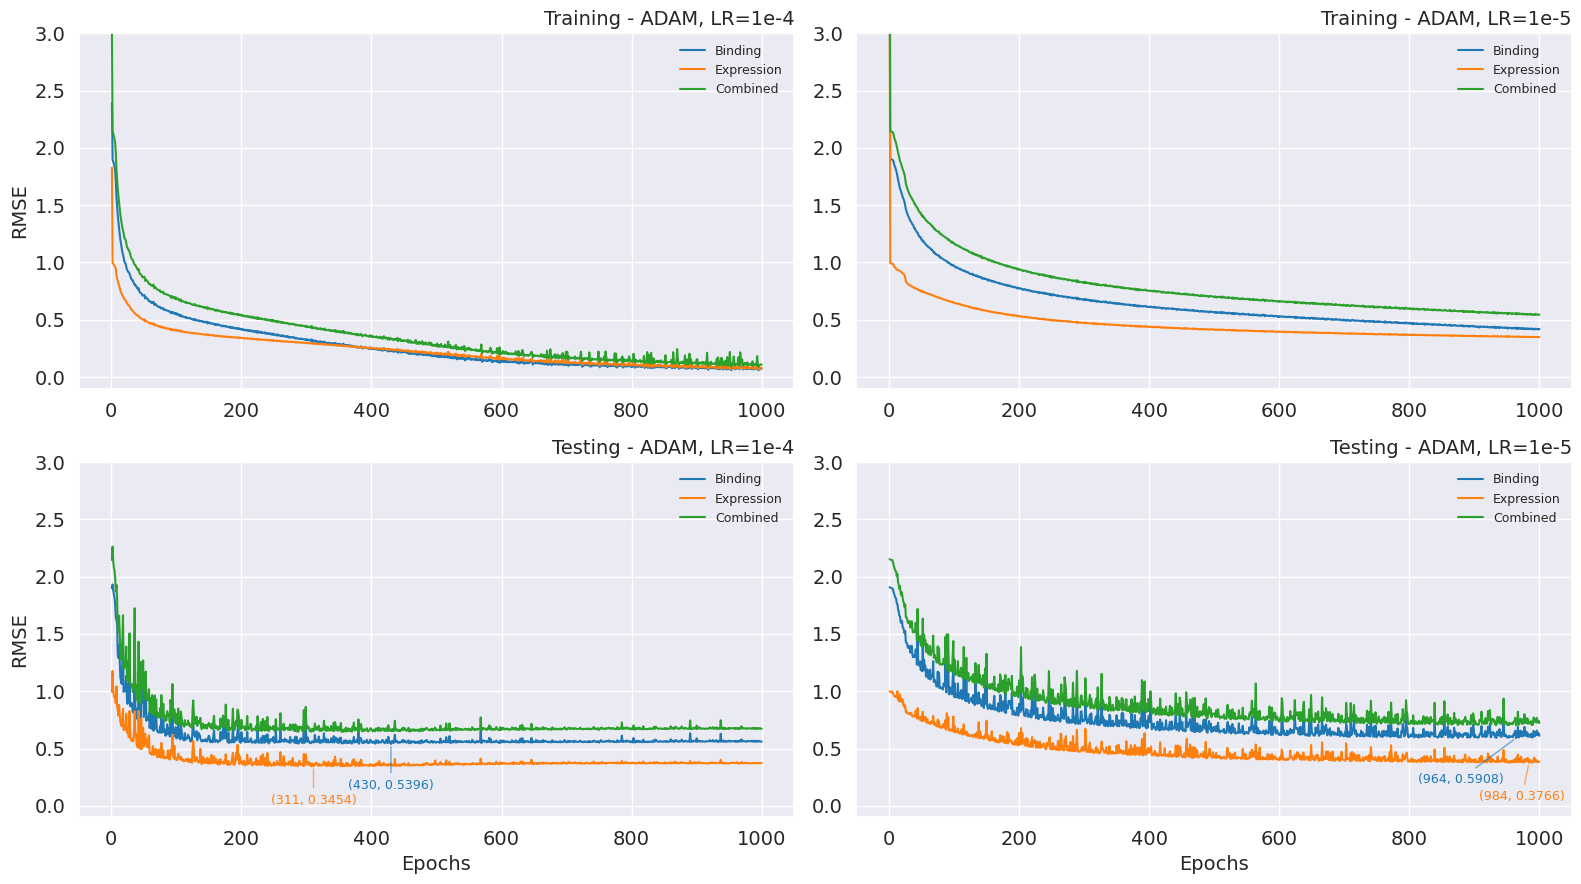

In [207]:
be_adam_lr_1e_neg_4 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-04.blstm_BE-ESM_AA_preembedded-DMS_OLD-2025-01-01_20-37/blstm_BE-ESM_AA_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/blstm-ESM_AA_preembedded/adam.lr1e-05.blstm_BE-ESM_AA_preembedded-DMS_OLD-2025-01-01_20-36/blstm_BE-ESM_AA_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm_BE-esm_aa_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-40,-25),
    "E, ADAM, LR:1e-5": (-5,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### BLSTM NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 946, rmse 1.9049
	Expression: epoch 676, rmse 0.9963
- ADAM, LR=1e-5:
	Binding: epoch 999, rmse 1.1148
	Expression: epoch 986, rmse 0.5834


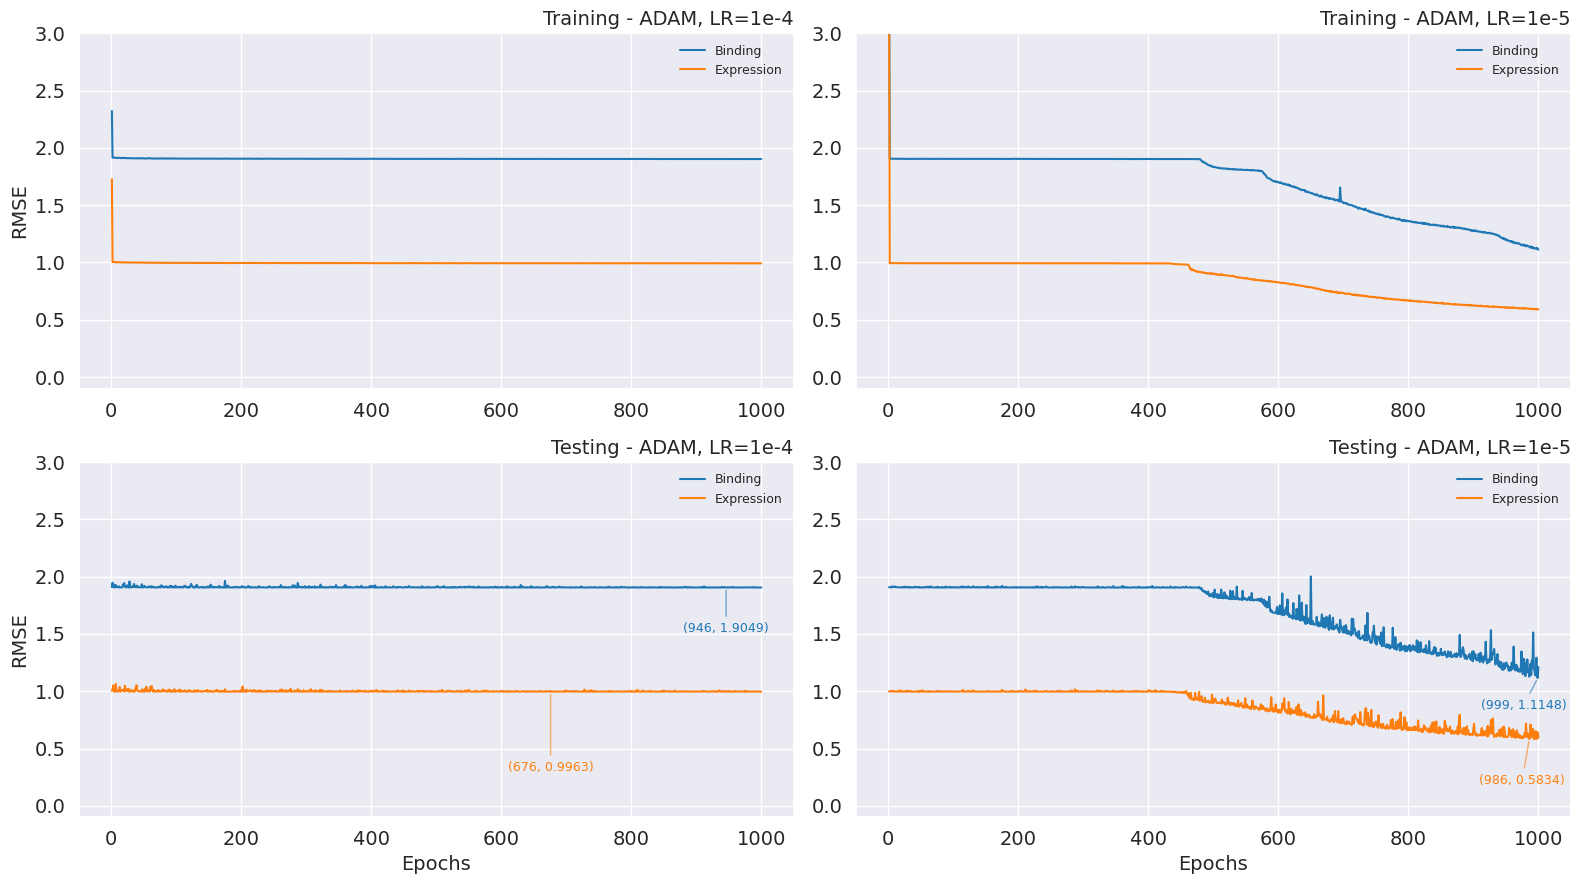

In [208]:
b_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-04.blstm-NLP_preembedded-DMS_OLD-binding-2024-12-05_11-05/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm-NLP_preembedded-DMS_OLD-binding-2024-12-05_04-05/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-04.blstm-NLP_preembedded-DMS_OLD-expression-2024-12-05_11-04/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm-NLP_preembedded-DMS_OLD-expression-2024-12-05_04-06/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm-nlp_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-25),
    "E, ADAM, LR:1e-4": (0,-50),
    "B, ADAM, LR:1e-5": (-10,-15),
    "E, ADAM, LR:1e-5": (-5,-25)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 816, rmse 1.9052
	Expression: epoch 78, rmse 0.9962
- ADAM, LR=1e-5:
	Binding: epoch 986, rmse 0.8658
	Expression: epoch 986, rmse 0.5520


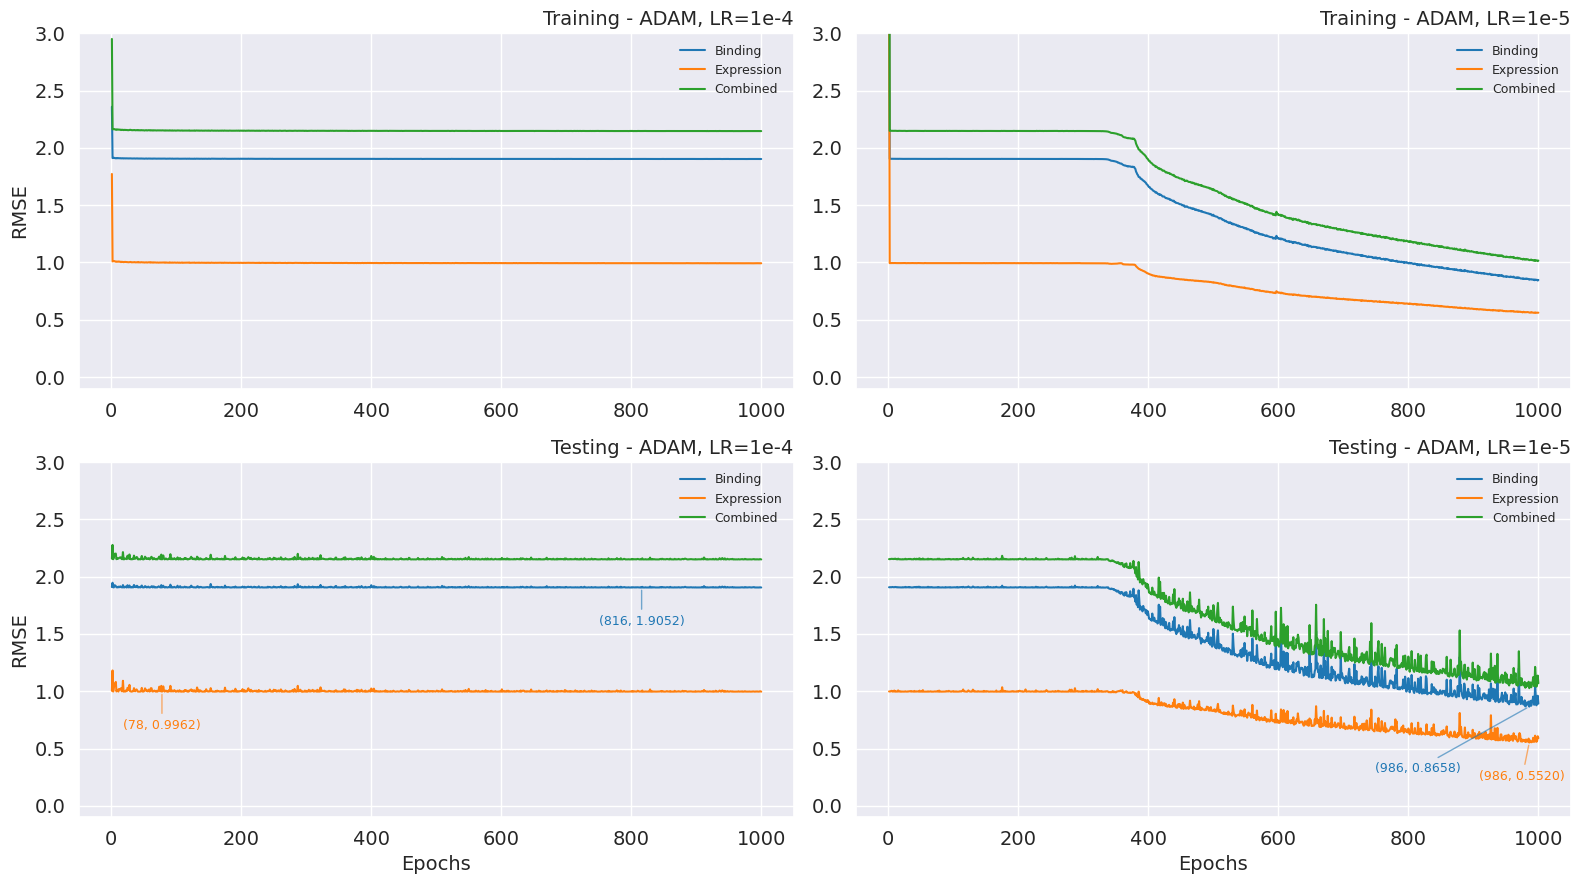

In [209]:
be_adam_lr_1e_neg_4 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-04.blstm_BE-NLP_preembedded-DMS_OLD-2025-01-02_14-36/blstm_BE-NLP_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/blstm-NLP_preembedded/adam.lr1e-05.blstm_BE-NLP_preembedded-DMS_OLD-2025-01-02_14-35/blstm_BE-NLP_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/blstm_BE-nlp_preembedded"
coords = {
    "B, ADAM, LR:1e-4": (0,-20),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-80,-40),
    "E, ADAM, LR:1e-5": (-5,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### GCN ESM-AA Preembedded

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 997, rmse 1.0719
	Expression: epoch 993, rmse 0.5409
- ADAM, LR=1e-5:
	Binding: epoch 1000, rmse 1.2945
	Expression: epoch 997, rmse 0.6805


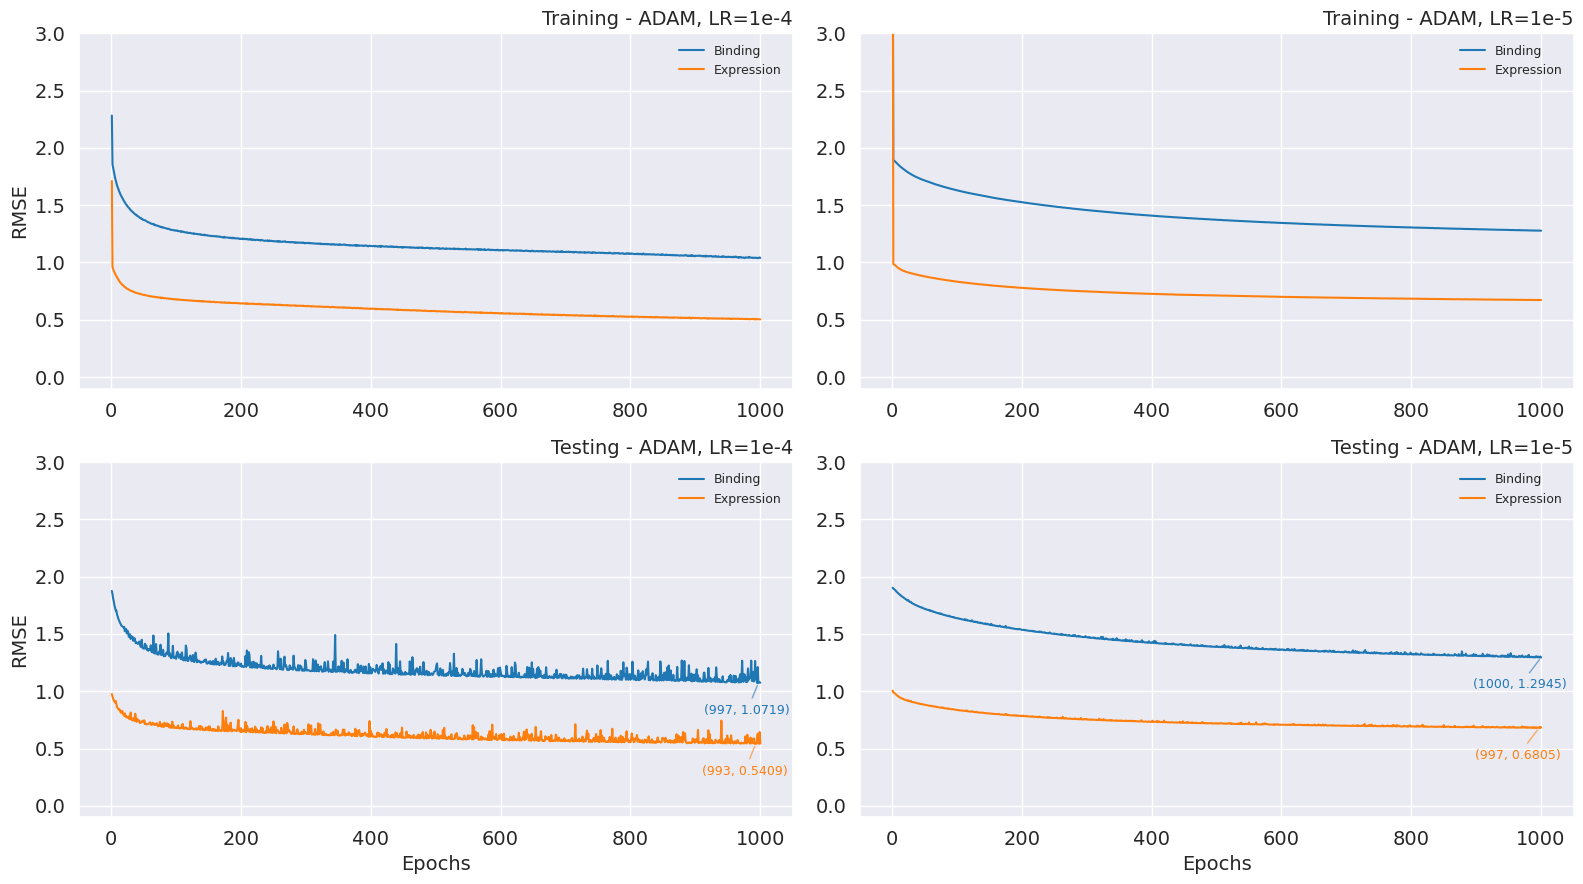

In [210]:
# OLD VERSION (no BE available)
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-12-05_01-01/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-binding-2024-12-04_14-49/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-12-05_00-48/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-expression-2024-12-04_14-55/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.old"
coords = {
    "B, ADAM, LR:1e-4": (-8,-15),
    "E, ADAM, LR:1e-4": (-8,-15),
    "B, ADAM, LR:1e-5": (-15,-15),
    "E, ADAM, LR:1e-5": (-15,-15)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 553, rmse 0.8813
	Expression: epoch 494, rmse 0.4759
- ADAM, LR=1e-5:
	Binding: epoch 1000, rmse 1.1182
	Expression: epoch 995, rmse 0.5974


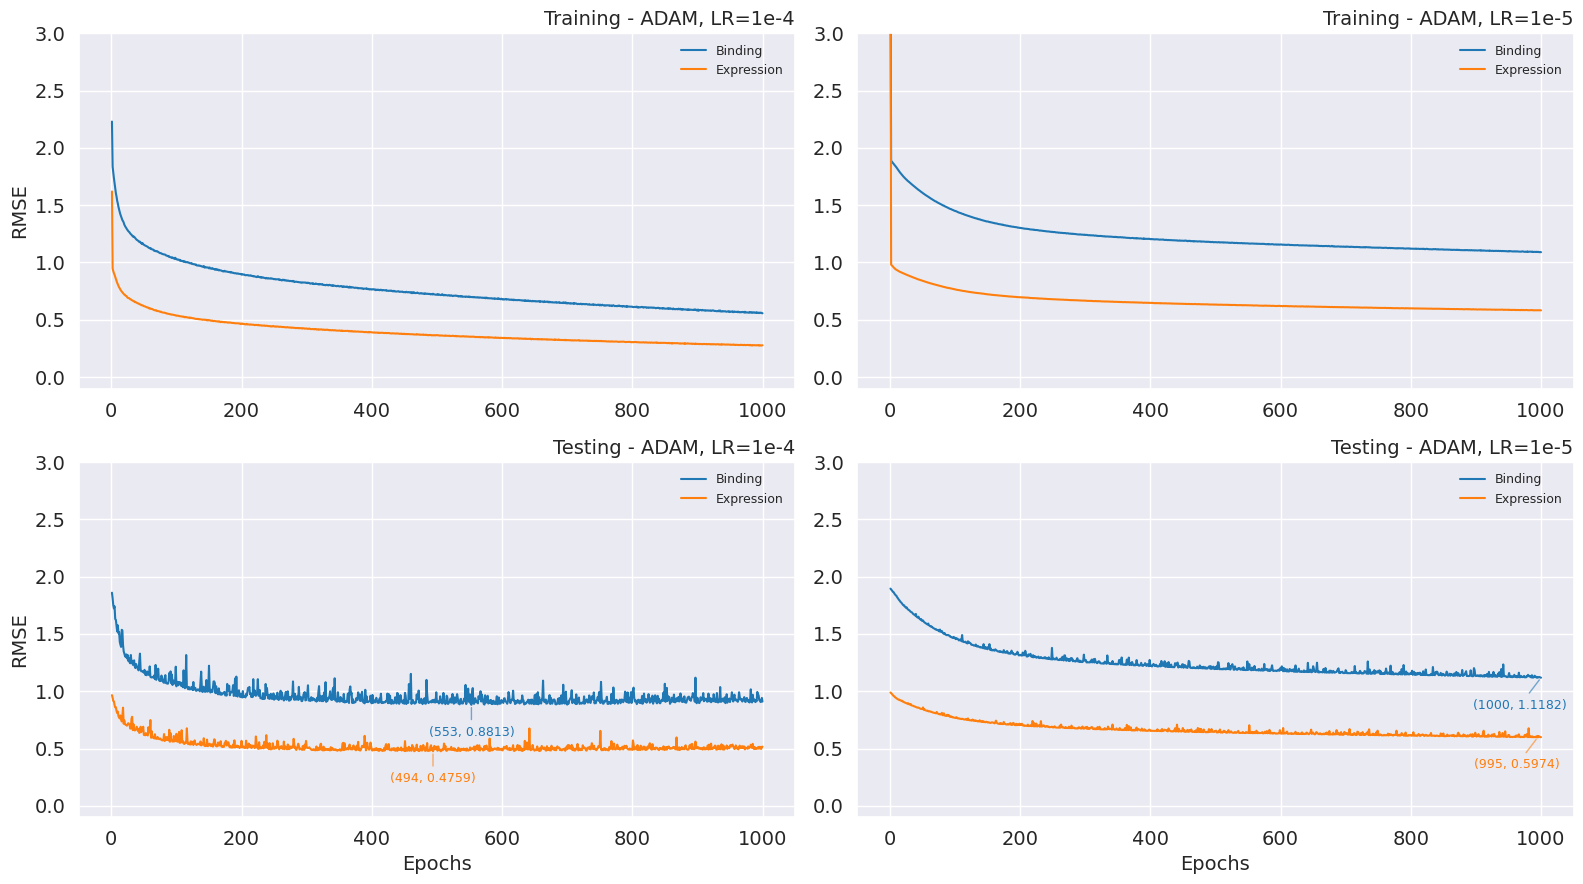

In [211]:
# NEW VERSION - single relu
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-binding-2025-01-03_15-23/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-binding-2025-01-03_04-28/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-expression-2025-01-03_15-25/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-expression-2025-01-03_04-32/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-15),
    "E, ADAM, LR:1e-4": (0,-15),
    "B, ADAM, LR:1e-5": (-15,-15),
    "E, ADAM, LR:1e-5": (-15,-15)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 721, rmse 0.8573
	Expression: epoch 989, rmse 0.4731
- ADAM, LR=1e-5:
	Binding: epoch 999, rmse 1.1390
	Expression: epoch 999, rmse 0.6558


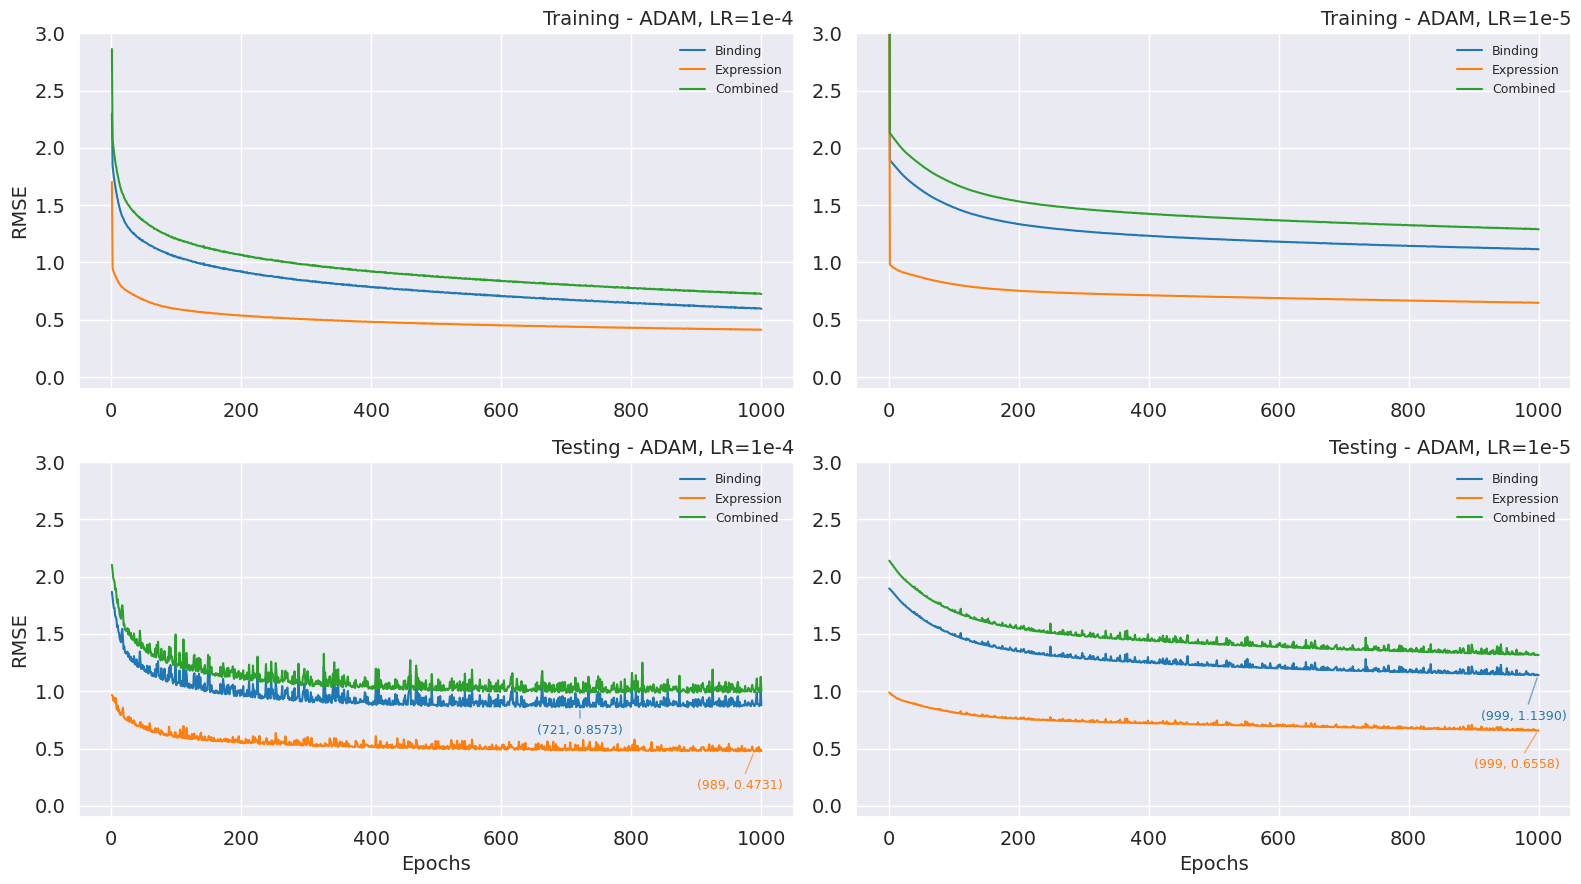

In [212]:
# NEW VERSION BE - double relu
be_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-04.gcn_BE-ESM_AA_preembedded-DMS_OLD-2025-01-02_21-52/gcn_BE-ESM_AA_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/adam.lr1e-05.gcn_BE-ESM_AA_preembedded-DMS_OLD-2025-01-02_21-50/gcn_BE-ESM_AA_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn_BE-esm_aa_preembedded.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-12),
    "E, ADAM, LR:1e-4": (-10,-20),
    "B, ADAM, LR:1e-5": (-10,-25),
    "E, ADAM, LR:1e-5": (-15,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 948, rmse 0.9441
	Expression: epoch 999, rmse 0.5022
- ADAM, LR=1e-5:
	Binding: epoch 992, rmse 1.1939
	Expression: epoch 990, rmse 0.6233


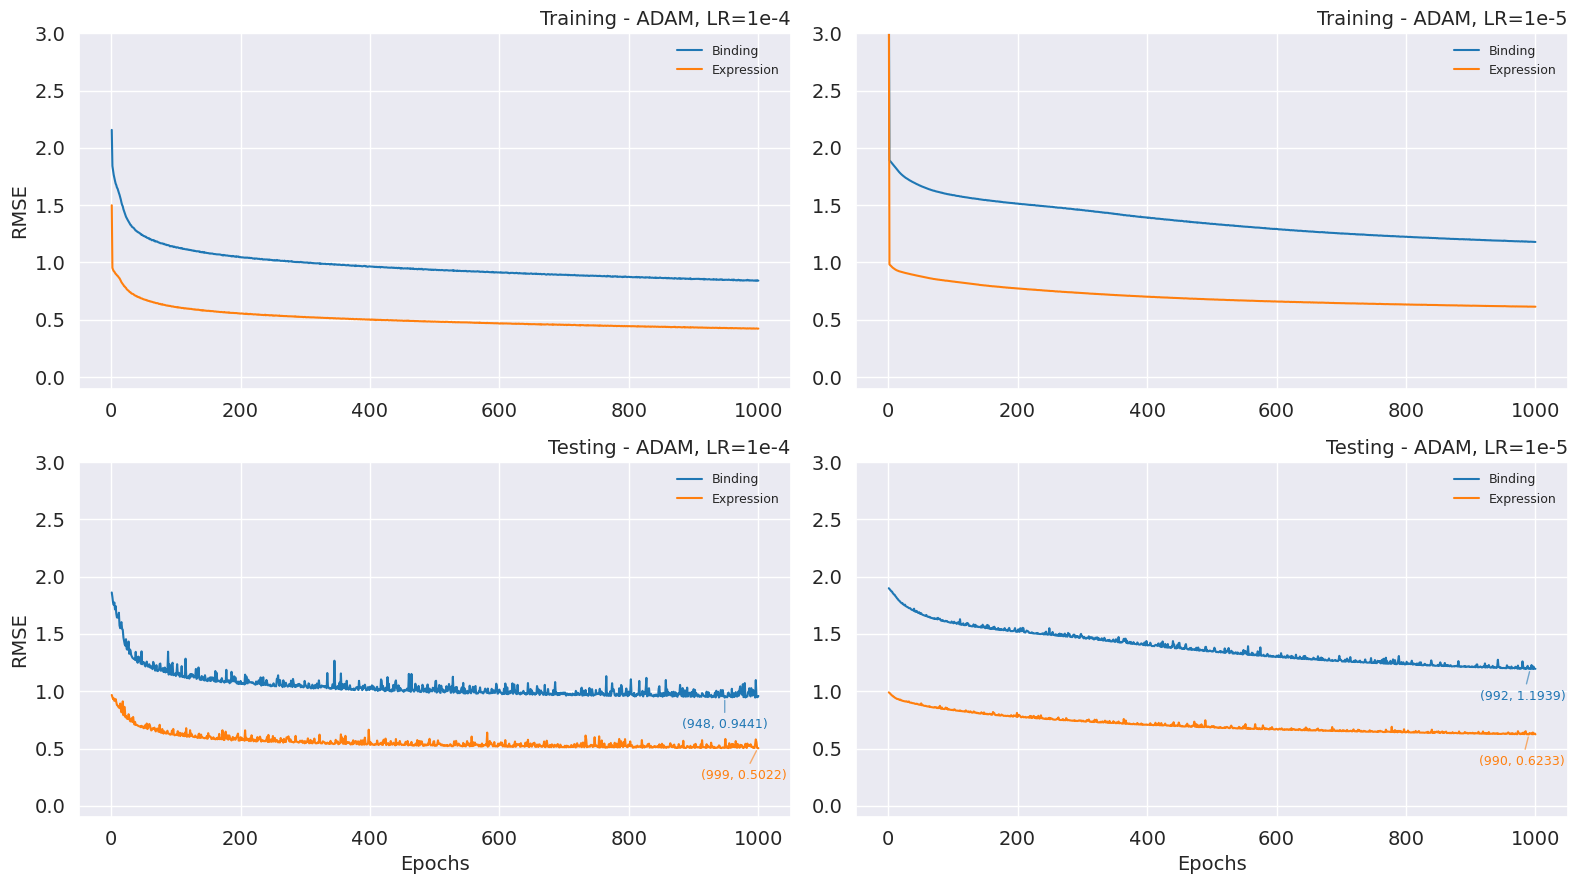

In [12]:
# NEW VERSION - single relu
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/single_relu-adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-binding-2025-01-10_19-09/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/single_relu-adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-binding-2025-01-11_04-55/gcn-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/single_relu-adam.lr1e-04.gcn-ESM_AA_preembedded-DMS_OLD-expression-2025-01-10_19-10/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/single_relu-adam.lr1e-05.gcn-ESM_AA_preembedded-DMS_OLD-expression-2025-01-11_04-55/gcn-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-esm_aa_preembedded.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-15),
    "E, ADAM, LR:1e-4": (-10,-15),
    "B, ADAM, LR:1e-5": (-5,-15),
    "E, ADAM, LR:1e-5": (-5,-15)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 947, rmse 0.9311
	Expression: epoch 968, rmse 0.5259
- ADAM, LR=1e-5:
	Binding: epoch 1000, rmse 1.2110
	Expression: epoch 996, rmse 0.6839


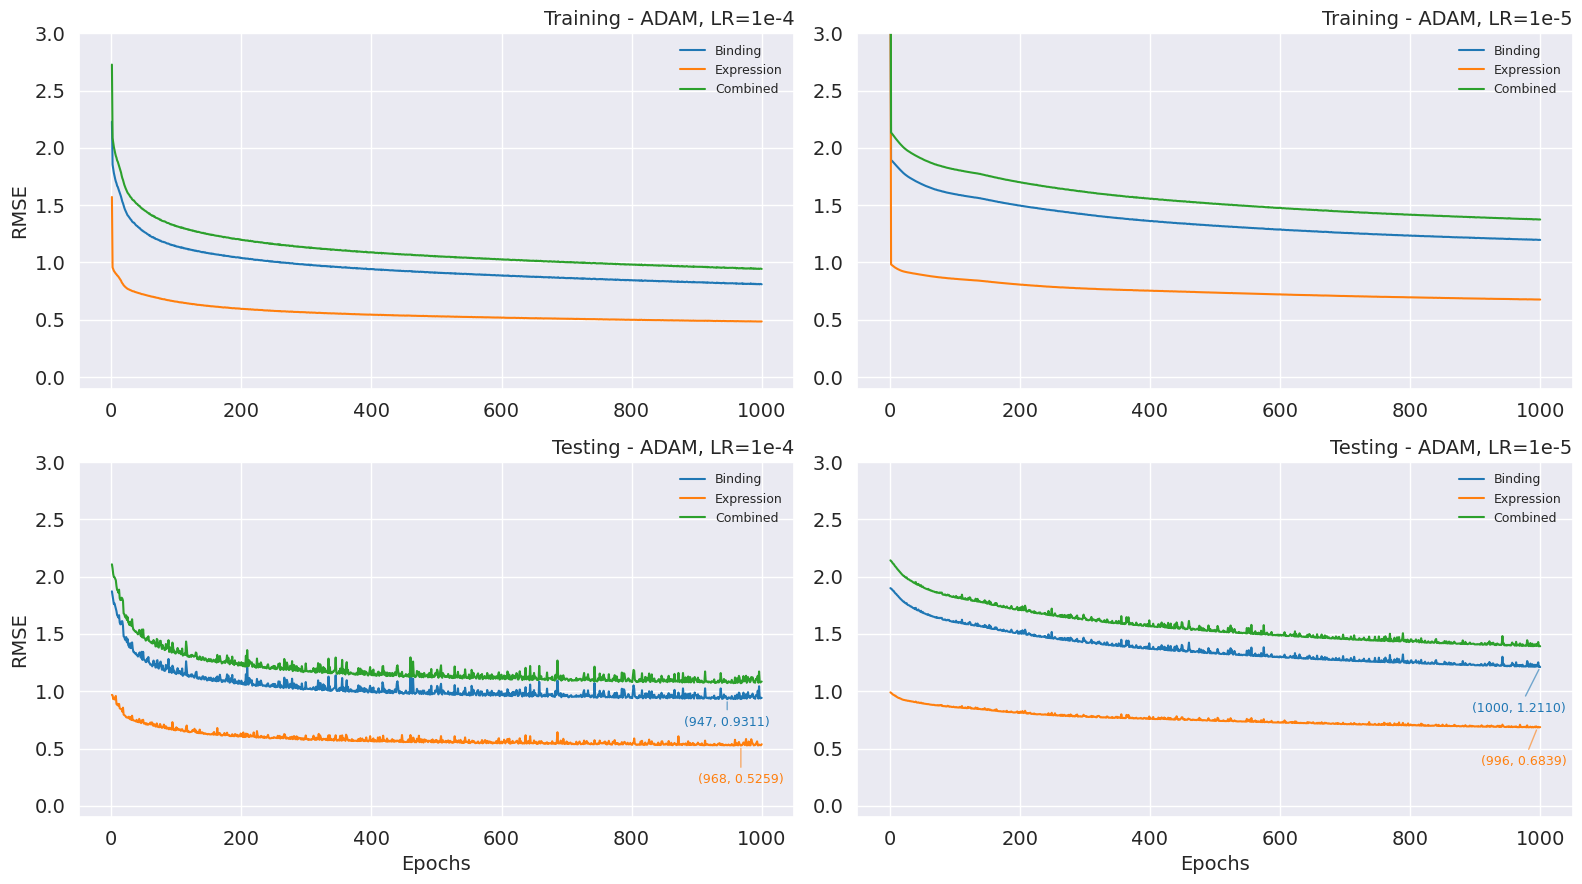

In [19]:
# NEW VERSION BE - single relu
be_adam_lr_1e_neg_4 = "../../results/run_results/gcn-ESM_AA_preembedded/single_relu-adam.lr1e-04.gcn_BE-ESM_AA_preembedded-DMS_OLD-2025-01-10_03-55/gcn_BE-ESM_AA_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/gcn-ESM_AA_preembedded/single_relu-adam.lr1e-05.gcn_BE-ESM_AA_preembedded-DMS_OLD-2025-01-10_03-54/gcn_BE-ESM_AA_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn_BE-esm_aa_preembedded.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-12),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-15,-25),
    "E, ADAM, LR:1e-5": (-10,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

---
### GCN NLP Preembedded w/ Finetuned BERT_MLM_ESM_INIT

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 989, rmse 1.2092
	Expression: epoch 999, rmse 0.6670
- ADAM, LR=1e-5:
	Binding: epoch 998, rmse 1.3947
	Expression: epoch 1000, rmse 0.7479


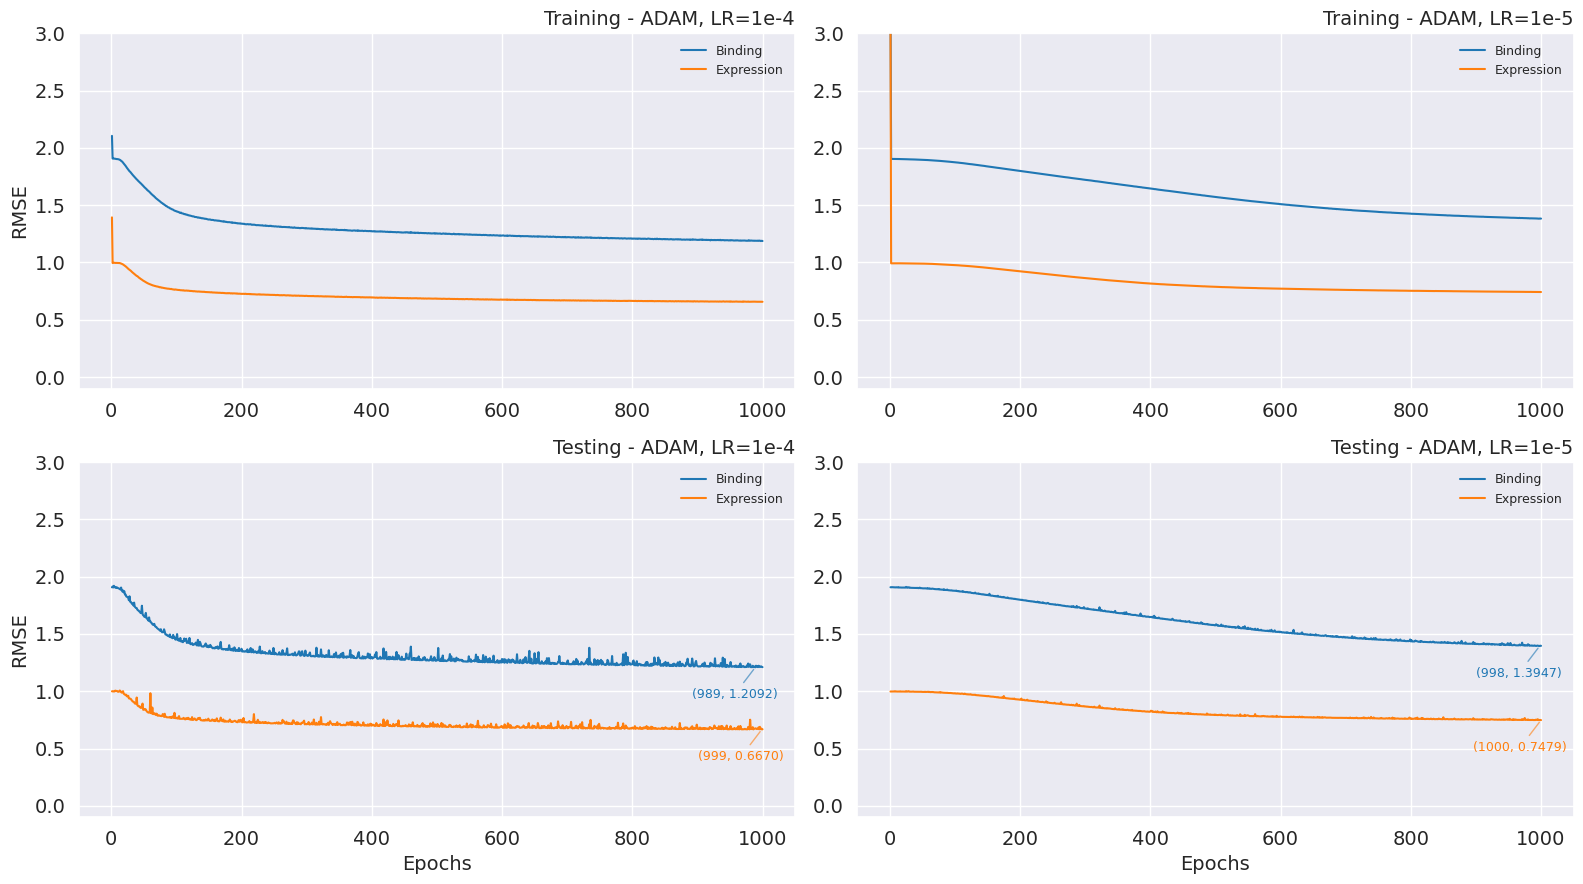

In [214]:
# OLD VERSION (no BE available)
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-binding-2024-12-05_09-14/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-binding-2024-12-05_09-11/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-expression-2024-12-05_09-13/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-expression-2024-12-05_09-12/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-nlp_preembedded.old"
coords = {
    "B, ADAM, LR:1e-4": (-15,-15),
    "E, ADAM, LR:1e-4": (-15,-15),
    "B, ADAM, LR:1e-5": (-15,-15),
    "E, ADAM, LR:1e-5": (-15,-15)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 936, rmse 1.1454
	Expression: epoch 966, rmse 0.6499
- ADAM, LR=1e-5:
	Binding: epoch 994, rmse 1.1969
	Expression: epoch 992, rmse 0.6816


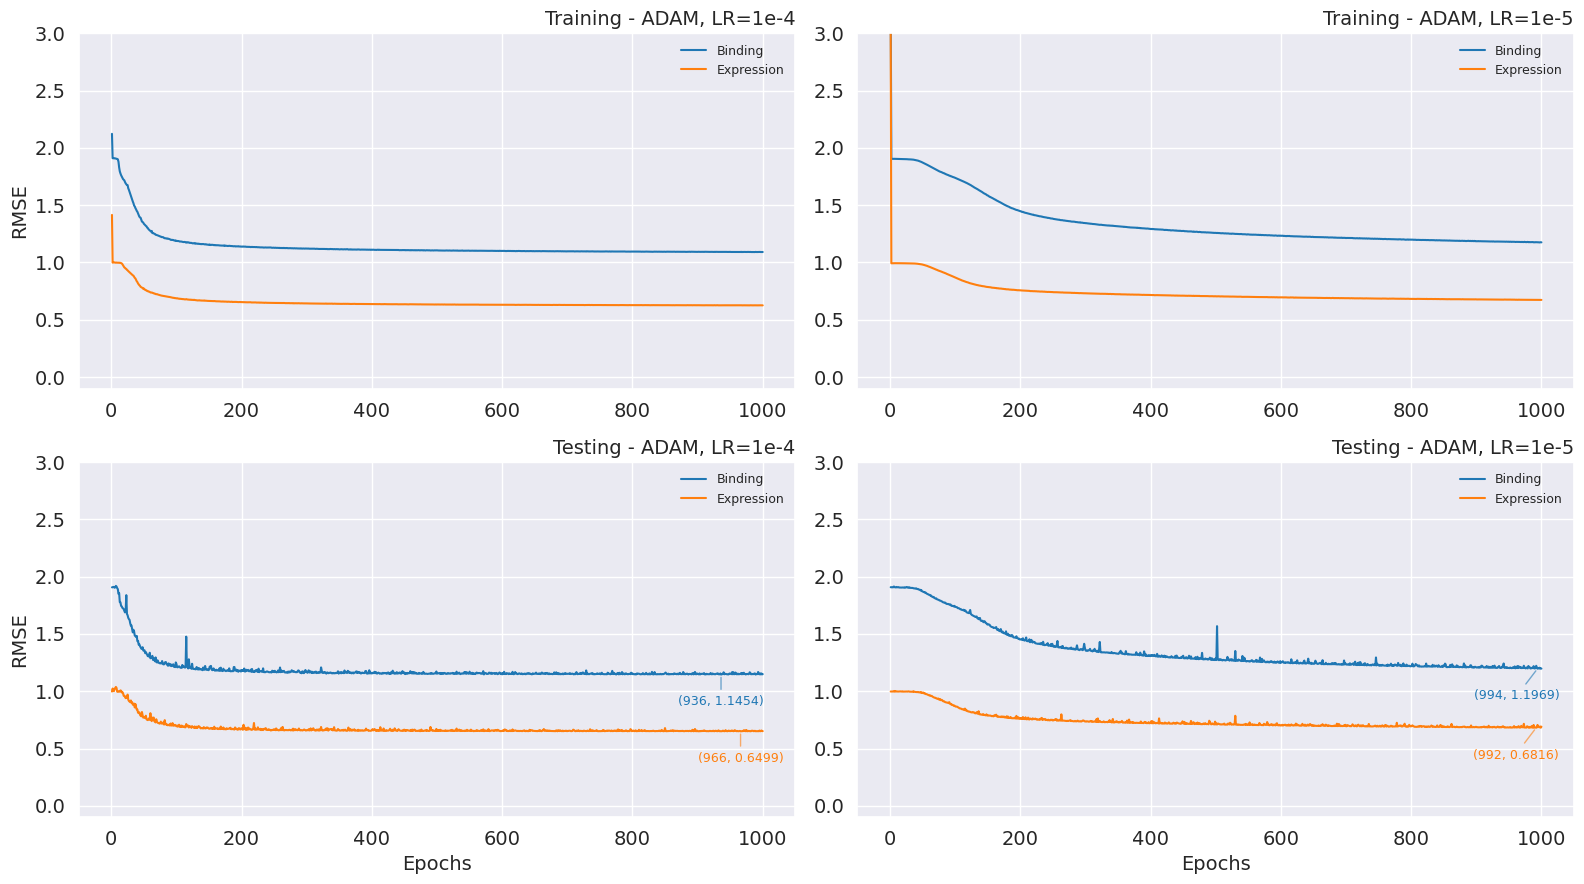

In [215]:
# NEW VERSION - double relu
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-binding-2025-01-03_22-53/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-binding-2025-01-04_21-45/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-expression-2025-01-04_12-12/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-expression-2025-01-05_11-32/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-nlp_preembedded.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-15),
    "E, ADAM, LR:1e-4": (0,-15),
    "B, ADAM, LR:1e-5": (-15,-15),
    "E, ADAM, LR:1e-5": (-15,-15)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 891, rmse 1.1452
	Expression: epoch 963, rmse 0.6513
- ADAM, LR=1e-5:
	Binding: epoch 996, rmse 1.2071
	Expression: epoch 999, rmse 0.7021


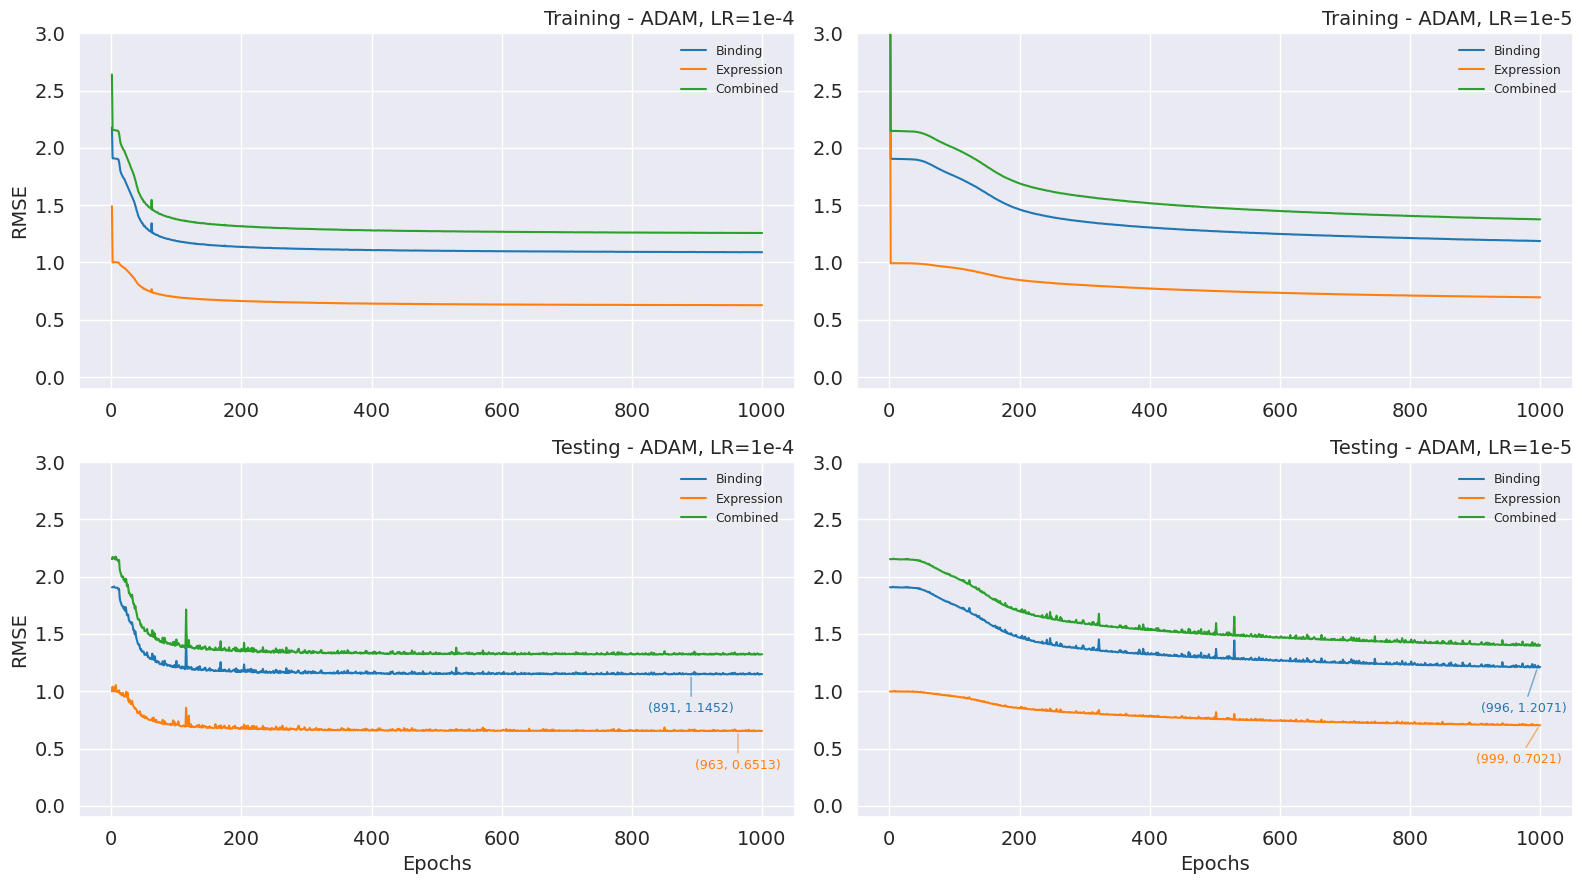

In [216]:
# NEW VERSION BE - double relu
be_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-04.gcn_BE-NLP_preembedded-DMS_OLD-2025-01-03_00-44/gcn_BE-NLP_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/adam.lr1e-05.gcn_BE-NLP_preembedded-DMS_OLD-2025-01-02_17-53/gcn_BE-NLP_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn_BE-nlp_preembedded.2relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-20),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-10,-25),
    "E, ADAM, LR:1e-5": (-15,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 994, rmse 1.1704
	Expression: epoch 996, rmse 0.6589
- ADAM, LR=1e-5:
	Binding: epoch 989, rmse 1.4161
	Expression: epoch 990, rmse 0.7316


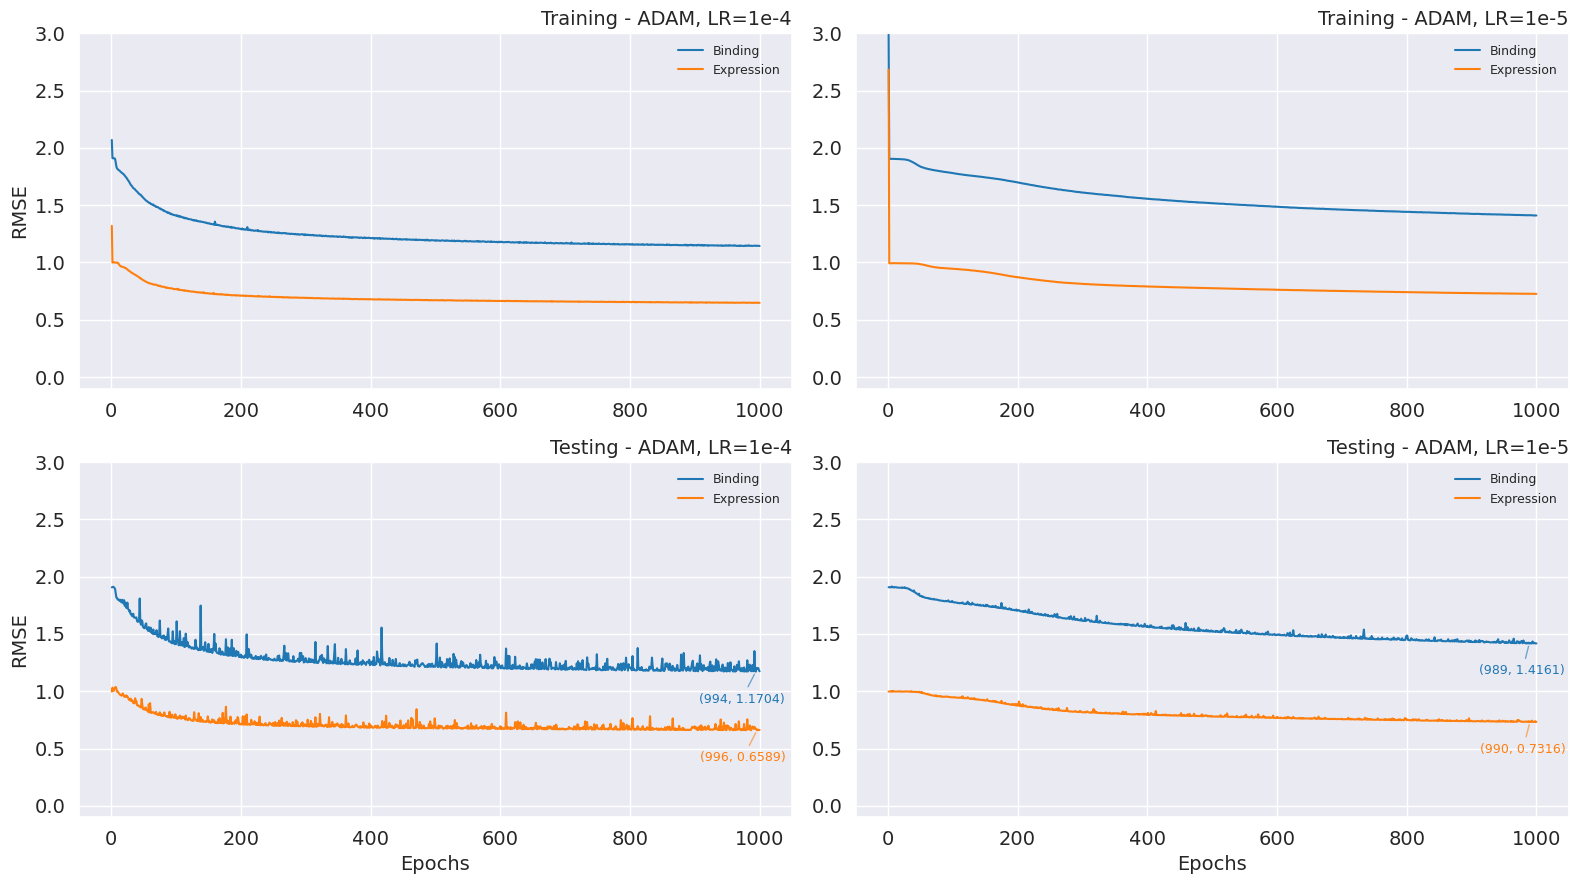

In [23]:
# NEW VERSION - single relu
b_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/single_relu-adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-binding-2025-01-12_19-26/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
b_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/single_relu-adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-binding-2025-01-11_16-11/gcn-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/single_relu-adam.lr1e-04.gcn-NLP_preembedded-DMS_OLD-expression-2025-01-12_06-42/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
e_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/single_relu-adam.lr1e-05.gcn-NLP_preembedded-DMS_OLD-expression-2025-01-12_00-43/gcn-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn-nlp_preembedded.1relu"
coords = {
    "B, ADAM, LR:1e-4": (-10,-15),
    "E, ADAM, LR:1e-4": (-10,-15),
    "B, ADAM, LR:1e-5": (-5,-15),
    "E, ADAM, LR:1e-5": (-5,-15)
}
plot_comparative_lr_log_file(b_adam_lr_1e_neg_4, b_adam_lr_1e_neg_5, e_adam_lr_1e_neg_4, e_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")

Best test RMSE at epoch x:
- ADAM, LR=1e-4:
	Binding: epoch 960, rmse 1.1616
	Expression: epoch 958, rmse 0.6688
- ADAM, LR=1e-5:
	Binding: epoch 1000, rmse 1.3576
	Expression: epoch 1000, rmse 0.7684


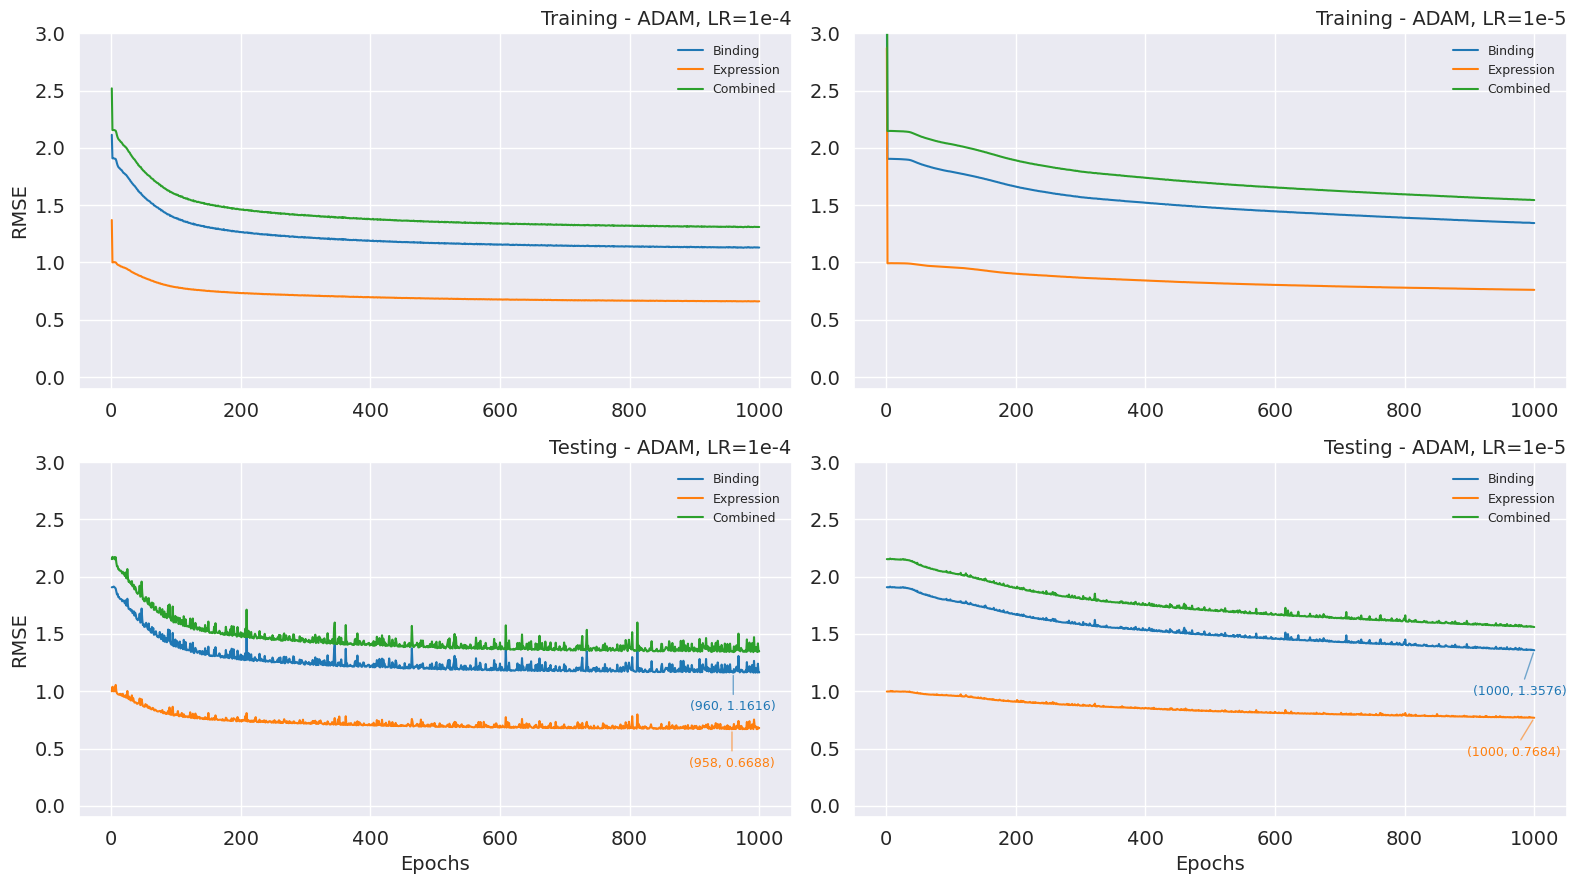

In [21]:
# NEW VERSION BE - single relu
be_adam_lr_1e_neg_4 = "../../results/run_results/gcn-NLP_preembedded/single_relu-adam.lr1e-04.gcn_BE-NLP_preembedded-DMS_OLD-2025-01-10_19-13/gcn_BE-NLP_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
be_adam_lr_1e_neg_5 = "../../results/run_results/gcn-NLP_preembedded/single_relu-adam.lr1e-05.gcn_BE-NLP_preembedded-DMS_OLD-2025-01-11_04-58/gcn_BE-NLP_preembedded-DMS_OLD-train_82178_test_20545_metrics.csv"
comparison_file = "../../results/plots/model_comparisons/finetuning/lr_comp/gcn_BE-nlp_preembedded.1relu"
coords = {
    "B, ADAM, LR:1e-4": (0,-20),
    "E, ADAM, LR:1e-4": (0,-20),
    "B, ADAM, LR:1e-5": (-10,-25),
    "E, ADAM, LR:1e-5": (-15,-20)
}
plot_comparative_lr_BE_log_file(be_adam_lr_1e_neg_4, be_adam_lr_1e_neg_5, coords, f"{comparison_file}.model_comp.pdf")